# 00 Paper Figure Storyboard

This notebook is a reading-oriented storyboard for the RouteRec paper figures.

It is intentionally more opinionated than the section-local notebooks under `01_` to `A05_`.
The goal is not only to render plots, but to answer three questions while reading top-to-bottom:

- Which figures are worth putting into the main paper?
- What evidence does each figure provide beyond a plain accuracy bar plot?
- Which artifacts already exist in `writing/results` or `experiments/run/artifacts/results/fmoe_n4/diag`, and which parts are still demo placeholders?

The notebook prefers actual local CSV/diagnostic artifacts when available, and falls back to demo data otherwise.


In [10]:
from pathlib import Path
import sys
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.lines import Line2D

RESULTS_ROOT = Path("/workspace/FeaturedMoE/writing/results")
DIAG_ROOT = Path("/workspace/FeaturedMoE/experiments/run/artifacts/results/fmoe_n4/diag")
ABLATION_LOG_ROOT = Path("/workspace/FeaturedMoE/experiments/run/artifacts/logs/fmoe_n4/ablation")
if str(RESULTS_ROOT) not in sys.path:
    sys.path.insert(0, str(RESULTS_ROOT))

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.alpha": 0.18,
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "legend.title_fontsize": 8,
})

GENERATED = RESULTS_ROOT / "generated_figures"
GENERATED.mkdir(parents=True, exist_ok=True)

ACTUAL_MODES = {"csv", "json", "summary", "artifact", "ablation", "result_json"}
DERIVED_MODES = {"proxy"}
DUMMY_MODES = {"demo", "empty", "missing"}


def story_note(title: str, body: str) -> None:
    display(Markdown(f"### {title}\n\n{body}"))


def _normalize_mode_payload(mode_payload):
    if isinstance(mode_payload, str):
        return {"data": mode_payload}
    if isinstance(mode_payload, dict):
        return mode_payload
    return {"data": str(mode_payload)}


def show_data_badge(mode_payload, detail: str | None = None) -> None:
    mode_map = _normalize_mode_payload(mode_payload)
    modes = {str(value) for value in mode_map.values()}
    if modes & DUMMY_MODES:
        label = "WARNING: DUMMY / SUBSTITUTE DATA"
        color = "#b91c1c"
        bg = "#fef2f2"
        extra = "주의: 이 출력에는 대체값 또는 데모 데이터가 포함되어 있다. 논문 본문 수치로 직접 인용하지 말고, 레이아웃/스토리 검토용으로만 사용해야 한다."
    elif modes & DERIVED_MODES:
        label = "CAUTION: PROXY / DERIVED VIEW"
        color = "#1d4ed8"
        bg = "#eff6ff"
        extra = "주의: 이 출력은 실제 raw artifact 대신 파생된 proxy view를 포함한다. 정성 시각화에는 쓸 수 있지만, 직접적인 정량 근거로 과대해석하면 안 된다."
    else:
        label = "REAL EXPERIMENT DATA"
        color = "#166534"
        bg = "#f0fdf4"
        extra = None
    detail_text = detail or ", ".join(f"{key}={value}" for key, value in mode_map.items())
    if extra is not None:
        detail_text = detail_text + "<br><br>" + extra
    display(Markdown(
        f"<div style='padding:10px 14px;border-radius:10px;border:2px solid {color};background:{bg};color:{color};font-weight:800;display:inline-block;letter-spacing:0.02em'>{label}</div>"
        f"<div style='margin-top:8px;color:#334155;font-size:13px;line-height:1.45'>{detail_text}</div>"
    ))


def load_csv_or_demo(csv_path, required_columns, demo_builder=None):
    csv_path = Path(csv_path)
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        missing = [column for column in required_columns if column not in df.columns]
        if missing:
            raise ValueError(f"{csv_path.name} is missing required columns: {missing}")
        if not df.empty:
            return df, "csv"
    if demo_builder is None:
        return pd.DataFrame(columns=required_columns), "empty"
    demo_df = demo_builder()
    return demo_df, "demo"


def export_figure(fig, output_stem, results_root, formats=("png", "pdf"), dpi=300):
    output_dir = Path(results_root) / "generated_figures"
    output_dir.mkdir(parents=True, exist_ok=True)
    saved_paths = []
    for extension in formats:
        output_path = output_dir / f"{output_stem}.{extension}"
        fig.savefig(output_path, dpi=dpi, bbox_inches="tight")
        saved_paths.append(output_path)
    return saved_paths


def _color_map(labels):
    cmap = plt.get_cmap("tab10")
    return {label: cmap(i % 10) for i, label in enumerate(labels)}


def _apply_tight_ylim(ax, values, zero_base=False, pad_ratio=0.08):
    finite_values = np.asarray([value for value in values if pd.notna(value)], dtype=float)
    if finite_values.size == 0:
        return
    min_value = float(finite_values.min())
    max_value = float(finite_values.max())
    if zero_base:
        lower = 0.0
        upper = max_value * (1.0 + pad_ratio) if max_value > 0 else 1.0
    else:
        span = max(max_value - min_value, max(abs(max_value), 1e-6) * 0.05)
        lower = min_value - span * pad_ratio
        upper = max_value + span * pad_ratio
        if min_value >= 0:
            lower = max(0.0, lower)
    if lower == upper:
        upper = lower + 1.0
    ax.set_ylim(lower, upper)


def grouped_barplot(data, x, hue, y, ax, title=None, ylabel=None, xlabel=None, rotate=0, zero_base=False, legend_title=None):
    data = data.copy()
    x_order = list(dict.fromkeys(data[x].tolist()))
    hue_order = list(dict.fromkeys(data[hue].tolist()))
    colors = _color_map(hue_order)
    width = 0.8 / max(len(hue_order), 1)
    positions = np.arange(len(x_order))
    plotted_values = []
    for idx, hue_value in enumerate(hue_order):
        subset = data[data[hue] == hue_value]
        values = []
        for x_value in x_order:
            match = subset[subset[x] == x_value]
            values.append(float(match.iloc[0][y]) if not match.empty else np.nan)
        plotted_values.extend([value for value in values if pd.notna(value)])
        offsets = positions - 0.4 + width / 2 + idx * width
        bars = ax.bar(offsets, values, width=width, label=str(hue_value), color=colors[hue_value], edgecolor="white", linewidth=0.8)
        for bar in bars:
            height = bar.get_height()
            if not np.isnan(height):
                ax.annotate(f"{height:.3f}", (bar.get_x() + bar.get_width() / 2, height), textcoords="offset points", xytext=(0, 3), ha="center", fontsize=7)
    ax.set_xticks(positions)
    ax.set_xticklabels(x_order, rotation=rotate)
    _apply_tight_ylim(ax, plotted_values, zero_base=zero_base)
    if title:
        ax.set_title(title)
    if ylabel:
        ax.set_ylabel(ylabel)
    if xlabel:
        ax.set_xlabel(xlabel)
    if hue_order:
        ax.legend(frameon=False, title=legend_title)


def lineplot_with_markers(data, x, y, hue, ax, title=None, ylabel=None, xlabel=None):
    data = data.copy()
    hue_order = list(dict.fromkeys(data[hue].tolist()))
    colors = _color_map(hue_order)
    plotted_values = []
    for hue_value in hue_order:
        subset = data[data[hue] == hue_value]
        y_values = subset[y].tolist()
        plotted_values.extend([value for value in y_values if pd.notna(value)])
        ax.plot(subset[x].tolist(), y_values, marker="o", linewidth=2.0, label=str(hue_value), color=colors[hue_value])
    _apply_tight_ylim(ax, plotted_values, zero_base=False)
    if title:
        ax.set_title(title)
    if ylabel:
        ax.set_ylabel(ylabel)
    if xlabel:
        ax.set_xlabel(xlabel)
    ax.legend(frameon=False)


def scatterplot_with_annotations(data, x, y, ax, hue=None, style=None, annotate_column=None, title=None, ylabel=None, xlabel=None):
    data = data.copy()
    labels = list(dict.fromkeys(data[hue].tolist())) if hue else ["series"]
    colors = _color_map(labels)
    markers = ["o", "s", "^", "D", "P", "X"]
    style_order = list(dict.fromkeys(data[style].tolist())) if style else [None]
    style_map = {value: markers[i % len(markers)] for i, value in enumerate(style_order)}
    plotted_y = []
    for _, row in data.iterrows():
        color = colors[row[hue]] if hue else "#4c72b0"
        marker = style_map[row[style]] if style else "o"
        ax.scatter(row[x], row[y], color=color, marker=marker, s=70, alpha=0.88)
        plotted_y.append(row[y])
        if annotate_column is not None:
            ax.annotate(str(row[annotate_column]), (row[x], row[y]), textcoords="offset points", xytext=(4, 4), fontsize=7)
    if title:
        ax.set_title(title)
    if ylabel:
        ax.set_ylabel(ylabel)
    if xlabel:
        ax.set_xlabel(xlabel)
    if plotted_y:
        _apply_tight_ylim(ax, plotted_y, zero_base=False)
    if hue:
        handles = [Line2D([0], [0], marker="o", color="w", label=str(label), markerfacecolor=colors[label], markersize=7) for label in labels]
        ax.legend(handles=handles, frameon=False, title=hue)


def lollipop_plot(data, category, value, ax, hue=None, title=None, ylabel=None, xlabel=None, rotate=0):
    data = data.copy()
    categories = list(dict.fromkeys(data[category].tolist()))
    if hue is None:
        values = [float(data.loc[data[category] == item, value].iloc[0]) for item in categories]
        positions = np.arange(len(categories))
        ax.hlines(positions, xmin=min(values), xmax=values, color="#cbd5e1", linewidth=2)
        ax.scatter(values, positions, color="#2563eb", s=60, zorder=3)
        ax.set_yticks(positions)
        ax.set_yticklabels(categories, rotation=rotate)
        _apply_tight_ylim(ax, positions, zero_base=False)
    else:
        hue_order = list(dict.fromkeys(data[hue].tolist()))
        colors = _color_map(hue_order)
        positions = np.arange(len(categories))
        offsets = np.linspace(-0.18, 0.18, num=max(len(hue_order), 1))
        all_values = []
        for idx, hue_value in enumerate(hue_order):
            subset = data[data[hue] == hue_value]
            value_list = []
            for item in categories:
                match = subset[subset[category] == item]
                value_list.append(float(match.iloc[0][value]) if not match.empty else np.nan)
            current_y = positions + offsets[idx]
            ax.hlines(current_y, xmin=np.nanmin(value_list), xmax=value_list, color=colors[hue_value], linewidth=1.6, alpha=0.35)
            ax.scatter(value_list, current_y, color=colors[hue_value], s=50, label=str(hue_value), zorder=3)
            all_values.extend([item for item in value_list if pd.notna(item)])
        ax.set_yticks(positions)
        ax.set_yticklabels(categories, rotation=rotate)
        if hue_order:
            ax.legend(frameon=False, title=hue)
        if all_values:
            span = max(all_values) - min(all_values)
            span = span if span > 0 else max(abs(max(all_values)), 1e-6) * 0.05
            ax.set_xlim(min(all_values) - span * 0.08, max(all_values) + span * 0.08)
    if title:
        ax.set_title(title)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)


def aggregate_prefix_columns(frame, prefix_column, value_column, group_column):
    frame = frame.copy()
    frame[group_column] = frame[prefix_column].str.split("_").str[0]
    grouped = frame.groupby([group_column], as_index=False)[value_column].sum()
    return grouped


def load_ablation_summary(summary_paths, allowed_stages=None, allowed_keys=None):
    rows = []
    for summary_path in summary_paths:
        summary_path = Path(summary_path)
        if not summary_path.exists():
            continue
        df = pd.read_csv(summary_path)
        df = df[df["trigger"].astype(str) == "run_complete"].copy()
        df = df[df["status"].astype(str).str.startswith("run_complete")].copy()
        if allowed_stages is not None:
            df = df[df["tuning_stage"].isin(allowed_stages)].copy()
        if allowed_keys is not None:
            df = df[df["setting_key"].isin(allowed_keys)].copy()
        if not df.empty:
            rows.append(df)
    if not rows:
        return pd.DataFrame(), "missing"
    merged = pd.concat(rows, ignore_index=True)
    return merged, "summary"


## Recommended Figure Set

A compact and persuasive paper story usually looks stronger when the figures answer different kinds of reviewer questions.

- `Main result`: does RouteRec improve ranking quality?
- `Routing control`: is the gain tied to behavior-guided routing rather than a generic MoE or bigger router?
- `Stage structure`: is the macro-mid-micro architecture chosen for a reason?
- `Cue sanity`: are compact cues enough, and does alignment actually matter?
- `Diagnostics / appendix`: does routing stay interpretable and non-collapsed?
- `PCA / geometry`: can we show an intuitive qualitative picture without overselling it as main evidence?

The table below is the suggested role split.


In [11]:
plan_df = pd.DataFrame(
    [
        ["Main paper", "Routing control", "Quality + consistency", "Shows the route is actually controlled by behavior cues, not just extra capacity"],
        ["Main paper", "Stage structure", "Ablation + order/layout comparison", "Shows why macro-mid-micro decomposition was chosen"],
        ["Main paper", "Cue sanity", "Compactness + perturbation drop", "Shows lightweight cues are enough, but alignment still matters"],
        ["Appendix", "Routing diagnostics", "Usage / entropy / family consistency", "Shows interpretability and anti-collapse behavior"],
        ["Appendix", "PCA view", "Feature or router-input geometry", "Useful as qualitative support, but weaker than quantitative sanity plots"],
    ],
    columns=["Placement", "Figure", "Primary message", "Why it helps"],
)
plan_df


,Placement,Figure,Primary message,Why it helps
0,Main paper,Routing control,Quality + consistency,Shows the route is actually controlled by beha...
1,Main paper,Stage structure,Ablation + order/layout comparison,Shows why macro-mid-micro decomposition was ch...
2,Main paper,Cue sanity,Compactness + perturbation drop,"Shows lightweight cues are enough, but alignme..."
3,Appendix,Routing diagnostics,Usage / entropy / family consistency,Shows interpretability and anti-collapse behavior
4,Appendix,PCA view,Feature or router-input geometry,"Useful as qualitative support, but weaker than..."


## 1. Routing Control: Quality Plus Consistency

This is one of the most important main-paper figures.

A pure performance bar plot can show `behavior-guided > shared FFN`, but it still leaves a reviewer wondering whether the gain is just due to another conditional module.
A second panel with a consistency curve answers a stronger question: **when two prefixes are behaviorally similar, does the router behave more similarly too?**

That second panel is what turns a "better model" figure into a "better routing mechanism" figure.


<div style='padding:10px 14px;border-radius:10px;border:2px solid #166534;background:#f0fdf4;color:#166534;font-weight:800;display:inline-block;letter-spacing:0.02em'>REAL EXPERIMENT DATA</div><div style='margin-top:8px;color:#334155;font-size:13px;line-height:1.45'>routing control 비교는 실제 ablation summary를 우선 사용합니다.</div>

Saved figures: /workspace/FeaturedMoE/writing/results/generated_figures/00_storyboard_routing_control.png, /workspace/FeaturedMoE/writing/results/generated_figures/00_storyboard_routing_control.pdf

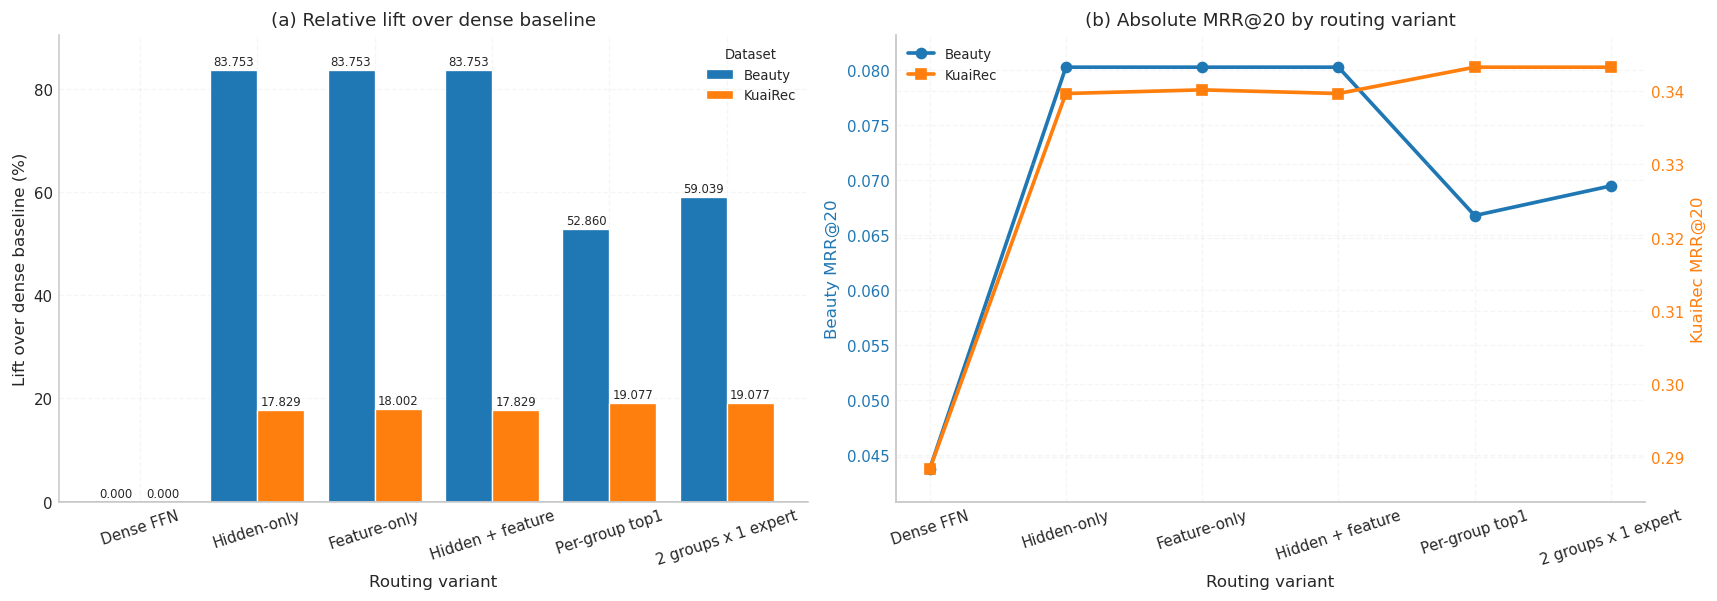

### 활용 포인트

왼쪽 패널은 데이터셋별 절대 스케일 차이를 제거하고, dense FFN 대비 상대 향상률만 비교하게 만든 그림이다. 오른쪽 패널은 같은 variant 순서를 유지한 채 Beauty와 KuaiRec의 절대 MRR을 좌우 축으로 분리해서 보여주므로, 어떤 routing 선택이 두 데이터셋에서 공통으로 유효한지 깔끔하게 읽을 수 있다. 논문 본문에서는 hidden+feature routing이 단순 hidden-only나 feature-only보다 일관되게 우세하고, sparsity를 강하게 주는 variant는 품질과 구조화 사이의 trade-off를 보여준다고 정리하면 된다.

In [12]:
QUALITY_PATH = RESULTS_ROOT / "02_routing_control/02a_routing_control_quality.csv"
CONSISTENCY_PATH = RESULTS_ROOT / "02_routing_control/02b_routing_control_consistency.csv"
QUALITY_COLUMNS = ["paper_section", "panel", "dataset", "variant_or_model", "metric", "cutoff", "value", "split", "selection_rule", "run_id", "source_path", "notes"]
CONSISTENCY_COLUMNS = ["paper_section", "panel", "dataset", "variant_or_model", "similarity_bucket", "consistency_value", "split", "selection_rule", "run_id", "source_path", "notes"]
ROUTING_SUMMARY_PATHS = [
    ABLATION_LOG_ROOT / "ablation_dualset_core_global_queue_v1/beauty/summary.csv",
    ABLATION_LOG_ROOT / "ablation_dualset_core_global_queue_v1/KuaiRecLargeStrictPosV2_0.2/summary.csv",
]
ROUTING_VARIANT_ORDER = [
    "SHARED_FFN",
    "ROUTER_SOURCE_HIDDEN",
    "ROUTER_SOURCE_FEATURE",
    "ROUTER_SOURCE_BOTH",
    "PER_GROUP_TOPK_1",
    "GROUP_TOPK_2_INNER1",
]
ROUTING_VARIANT_LABELS = {
    "SHARED_FFN": "Dense FFN",
    "ROUTER_SOURCE_HIDDEN": "Hidden-only",
    "ROUTER_SOURCE_FEATURE": "Feature-only",
    "ROUTER_SOURCE_BOTH": "Hidden + feature",
    "PER_GROUP_TOPK_1": "Per-group top1",
    "GROUP_TOPK_2_INNER1": "2 groups x 1 expert",
}
ROUTING_DATASET_LABELS = {
    "beauty": "Beauty",
    "KuaiRecLargeStrictPosV2_0.2": "KuaiRec",
}


def demo_quality() -> pd.DataFrame:
    rows = []
    datasets = ["Beauty", "KuaiRec"]
    values = {
        "Dense FFN": [0.0446, 0.2897],
        "Hidden-only": [0.0798, 0.3388],
        "Feature-only": [0.0801, 0.3391],
        "Hidden + feature": [0.0806, 0.3398],
        "Per-group top1": [0.0668, 0.3433],
        "2 groups x 1 expert": [0.0695, 0.3433],
    }
    for variant, scores in values.items():
        for dataset, value in zip(datasets, scores):
            rows.append({
                "dataset": dataset,
                "variant": variant,
                "test_mrr20": value,
            })
    return pd.DataFrame(rows)


def load_routing_control_actual():
    routing_df, routing_mode = load_ablation_summary(
        ROUTING_SUMMARY_PATHS,
        allowed_stages=["routing_control"],
        allowed_keys=ROUTING_VARIANT_ORDER,
    )
    if routing_df.empty:
        demo_df = demo_quality()
        demo_baseline = demo_df[demo_df["variant"] == "Dense FFN"][["dataset", "test_mrr20"]].rename(columns={"test_mrr20": "baseline_mrr20"})
        demo_df = demo_df.merge(demo_baseline, on="dataset", how="left")
        demo_df["lift_pct"] = (demo_df["test_mrr20"] / demo_df["baseline_mrr20"] - 1.0) * 100.0
        return demo_df, "demo"

    grouped = (
        routing_df.groupby(["dataset", "setting_key"], as_index=False)
        .agg(
            test_mrr20=("test_mrr20", "median"),
            seed_count=("seed_id", "nunique"),
            setting_detail=("setting_detail", "first"),
        )
    )
    grouped["dataset"] = grouped["dataset"].map(ROUTING_DATASET_LABELS).fillna(grouped["dataset"])
    grouped["variant"] = grouped["setting_key"].map(ROUTING_VARIANT_LABELS).fillna(grouped["setting_key"])
    baseline = grouped[grouped["setting_key"] == "SHARED_FFN"][["dataset", "test_mrr20"]].rename(columns={"test_mrr20": "baseline_mrr20"})
    grouped = grouped.merge(baseline, on="dataset", how="left")
    grouped["lift_pct"] = (grouped["test_mrr20"] / grouped["baseline_mrr20"] - 1.0) * 100.0
    return grouped, "summary"


routing_plot_df, routing_mode = load_routing_control_actual()
routing_plot_df["variant"] = pd.Categorical(
    routing_plot_df["variant"],
    categories=[ROUTING_VARIANT_LABELS[key] for key in ROUTING_VARIANT_ORDER],
    ordered=True,
)
routing_plot_df = routing_plot_df.sort_values(["dataset", "variant"])
show_data_badge({"routing_control": routing_mode}, "routing control 비교는 실제 ablation summary를 우선 사용합니다.")

fig, axes = plt.subplots(1, 2, figsize=(14.2, 4.9), constrained_layout=True)
grouped_barplot(
    routing_plot_df,
    x="variant",
    hue="dataset",
    y="lift_pct",
    ax=axes[0],
    title="(a) Relative lift over dense baseline",
    ylabel="Lift over dense baseline (%)",
    xlabel="Routing variant",
    rotate=18,
    zero_base=False,
    legend_title="Dataset",
)
axes[0].axhline(0.0, color="#94a3b8", linewidth=1.0)

variant_order = [ROUTING_VARIANT_LABELS[key] for key in ROUTING_VARIANT_ORDER]
dataset_order = [dataset for dataset in ["Beauty", "KuaiRec"] if dataset in routing_plot_df["dataset"].unique()]
line_colors = _color_map(dataset_order)
axes[1].set_xticks(np.arange(len(variant_order)))
axes[1].set_xticklabels(variant_order, rotation=18)
axes[1].set_title("(b) Absolute MRR@20 by routing variant")
axes[1].set_xlabel("Routing variant")

left_dataset = dataset_order[0] if dataset_order else None
right_dataset = dataset_order[1] if len(dataset_order) > 1 else None
if left_dataset is not None:
    left_df = routing_plot_df[routing_plot_df["dataset"] == left_dataset]
    left_y = [float(left_df[left_df["variant"] == variant]["test_mrr20"].iloc[0]) if not left_df[left_df["variant"] == variant].empty else np.nan for variant in variant_order]
    axes[1].plot(np.arange(len(variant_order)), left_y, marker="o", linewidth=2.2, color=line_colors[left_dataset], label=left_dataset)
    axes[1].set_ylabel(f"{left_dataset} MRR@20", color=line_colors[left_dataset])
    axes[1].tick_params(axis="y", labelcolor=line_colors[left_dataset])
    _apply_tight_ylim(axes[1], [item for item in left_y if pd.notna(item)], zero_base=False)
if right_dataset is not None:
    ax_right = axes[1].twinx()
    right_df = routing_plot_df[routing_plot_df["dataset"] == right_dataset]
    right_y = [float(right_df[right_df["variant"] == variant]["test_mrr20"].iloc[0]) if not right_df[right_df["variant"] == variant].empty else np.nan for variant in variant_order]
    ax_right.plot(np.arange(len(variant_order)), right_y, marker="s", linewidth=2.2, color=line_colors[right_dataset], label=right_dataset)
    ax_right.set_ylabel(f"{right_dataset} MRR@20", color=line_colors[right_dataset])
    ax_right.tick_params(axis="y", labelcolor=line_colors[right_dataset])
    _apply_tight_ylim(ax_right, [item for item in right_y if pd.notna(item)], zero_base=False)
    legend_handles = [
        Line2D([0], [0], color=line_colors[left_dataset], marker="o", linewidth=2.2, label=left_dataset),
        Line2D([0], [0], color=line_colors[right_dataset], marker="s", linewidth=2.2, label=right_dataset),
    ]
    axes[1].legend(handles=legend_handles, frameon=False, loc="upper left")
else:
    axes[1].legend(frameon=False, loc="upper left")

saved_paths = export_figure(fig, "00_storyboard_routing_control", RESULTS_ROOT)
display(Markdown("Saved figures: " + ", ".join(str(path) for path in saved_paths)))
plt.show()

story_note(
    "활용 포인트",
    "왼쪽 패널은 데이터셋별 절대 스케일 차이를 제거하고, dense FFN 대비 상대 향상률만 비교하게 만든 그림이다. 오른쪽 패널은 같은 variant 순서를 유지한 채 Beauty와 KuaiRec의 절대 MRR을 좌우 축으로 분리해서 보여주므로, 어떤 routing 선택이 두 데이터셋에서 공통으로 유효한지 깔끔하게 읽을 수 있다. 논문 본문에서는 hidden+feature routing이 단순 hidden-only나 feature-only보다 일관되게 우세하고, sparsity를 강하게 주는 variant는 품질과 구조화 사이의 trade-off를 보여준다고 정리하면 된다."
)


## 2. Stage Structure: Why This Architecture

This figure should answer a design question, not just another performance question.

A clean version is usually:

- `Panel A`: remove macro, remove mid, remove micro, single-stage, dense full.
- `Panel B`: compare the chosen order/layout against a few credible alternatives.

That combination lets you say both:

- staged decomposition matters, and
- the exact coarse-to-fine composition was not arbitrary.


<div style='padding:10px 14px;border-radius:10px;border:2px solid #166534;background:#f0fdf4;color:#166534;font-weight:800;display:inline-block;letter-spacing:0.02em'>REAL EXPERIMENT DATA</div><div style='margin-top:8px;color:#334155;font-size:13px;line-height:1.45'>stage structure 비교는 first-primary ablation summary를 우선 사용합니다.</div>

Saved figures: /workspace/FeaturedMoE/writing/results/generated_figures/00_storyboard_stage_structure.png, /workspace/FeaturedMoE/writing/results/generated_figures/00_storyboard_stage_structure.pdf

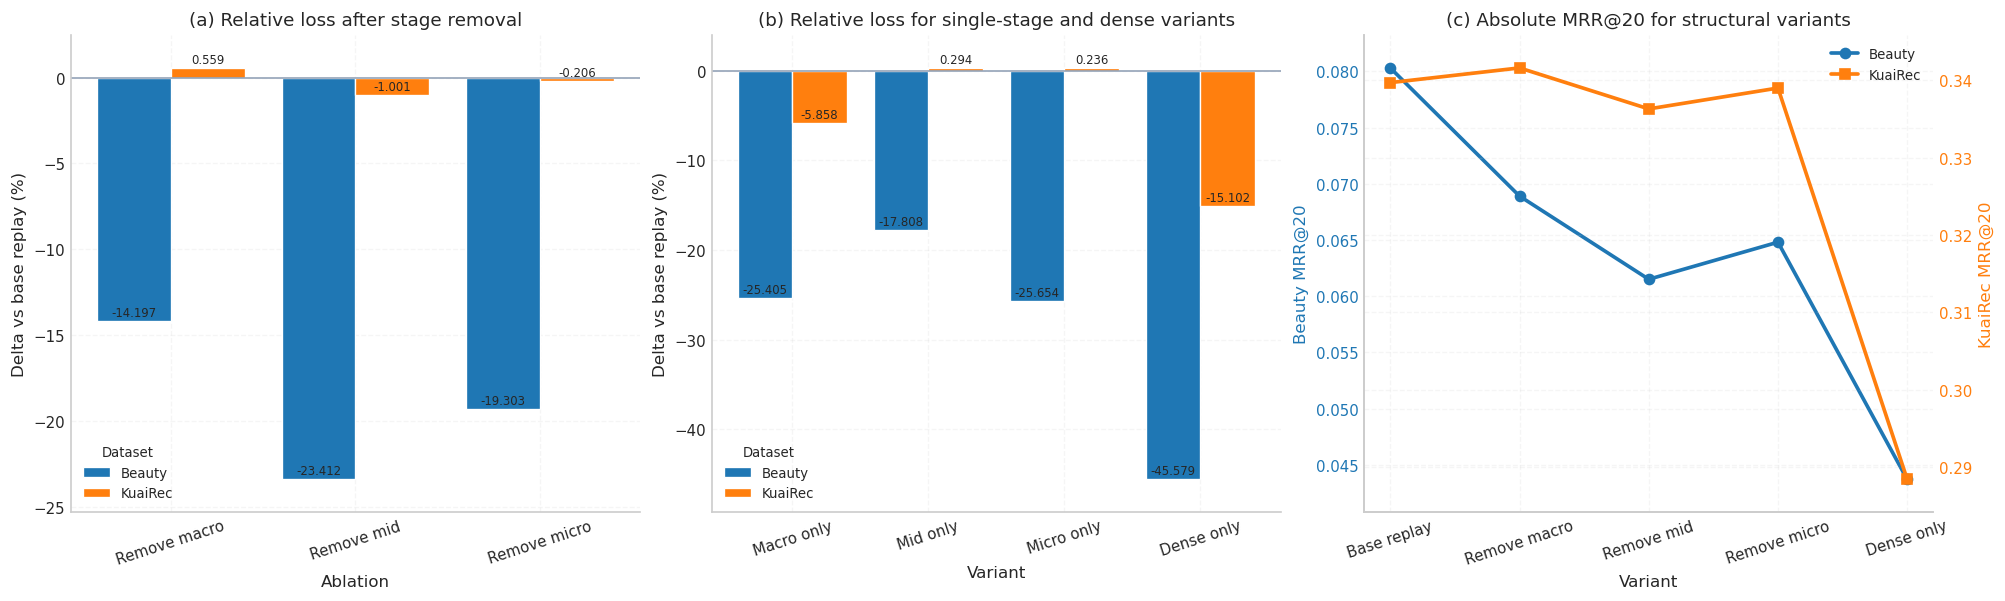

### 활용 포인트

이 그림은 staged decomposition이 그냥 sparse라서 좋은 것이 아니라, 어떤 stage를 지우느냐에 따라 손실 양상이 다르다는 점을 보여준다. 왼쪽과 가운데 패널은 데이터셋 간 절대 스케일 차이를 제거한 상대 손실이므로 비교가 쉽고, 오른쪽 패널은 base replay와 dense-only를 함께 보여주면서 구조적 선택이 실제 성능 차이로 이어진다는 점을 좌우 축으로 깔끔하게 읽게 해준다. 본문에서는 macro-mid-micro 분해가 단순 dense 대체보다 낫고, 특정 stage 제거가 일관된 손실을 만든다고 요약하면 된다.

In [13]:
STAGE_PATH = RESULTS_ROOT / "03_stage_structure/03a_stage_ablation.csv"
DENSE_PATH = RESULTS_ROOT / "03_stage_structure/03b_dense_vs_staged.csv"
WRAPPER_PATH = RESULTS_ROOT / "03_stage_structure/03c_wrapper_order.csv"
STAGE_COLUMNS = ["paper_section", "panel", "dataset", "variant_or_model", "ablation_group", "metric", "cutoff", "value", "split", "selection_rule", "run_id", "source_path", "notes"]
DENSE_COLUMNS = ["paper_section", "panel", "dataset", "variant_or_model", "layout_variant", "stage_count", "metric", "cutoff", "value", "split", "selection_rule", "run_id", "source_path", "notes"]
WRAPPER_COLUMNS = ["paper_section", "panel", "dataset", "variant_or_model", "wrapper_variant", "stage_order", "metric", "cutoff", "value", "split", "selection_rule", "run_id", "source_path", "notes"]
STAGE_SUMMARY_PATHS = [
    ABLATION_LOG_ROOT / "ablation_dualset_core_global_queue_v1_first_primary/beauty/summary.csv",
    ABLATION_LOG_ROOT / "ablation_dualset_core_global_queue_v1_first_primary/KuaiRecLargeStrictPosV2_0.2/summary.csv",
]
STAGE_VARIANT_ORDER = [
    "BASE_REPLAY",
    "REMOVE_MACRO",
    "REMOVE_MID",
    "REMOVE_MICRO",
    "SINGLE_STAGE_MACRO",
    "SINGLE_STAGE_MID",
    "SINGLE_STAGE_MICRO",
    "DENSE_FULL_ONLY",
]
STAGE_LABELS = {
    "BASE_REPLAY": "Base replay",
    "REMOVE_MACRO": "Remove macro",
    "REMOVE_MID": "Remove mid",
    "REMOVE_MICRO": "Remove micro",
    "SINGLE_STAGE_MACRO": "Macro only",
    "SINGLE_STAGE_MID": "Mid only",
    "SINGLE_STAGE_MICRO": "Micro only",
    "DENSE_FULL_ONLY": "Dense only",
}
STAGE_DATASET_LABELS = {
    "beauty": "Beauty",
    "KuaiRecLargeStrictPosV2_0.2": "KuaiRec",
}


def demo_stage_actual():
    rows = pd.DataFrame([
        {"dataset": "Beauty", "setting_key": "BASE_REPLAY", "test_mrr20": 0.0803},
        {"dataset": "Beauty", "setting_key": "REMOVE_MACRO", "test_mrr20": 0.0689},
        {"dataset": "Beauty", "setting_key": "REMOVE_MID", "test_mrr20": 0.0615},
        {"dataset": "Beauty", "setting_key": "REMOVE_MICRO", "test_mrr20": 0.0648},
        {"dataset": "Beauty", "setting_key": "SINGLE_STAGE_MACRO", "test_mrr20": 0.0599},
        {"dataset": "Beauty", "setting_key": "SINGLE_STAGE_MID", "test_mrr20": 0.0660},
        {"dataset": "Beauty", "setting_key": "SINGLE_STAGE_MICRO", "test_mrr20": 0.0597},
        {"dataset": "Beauty", "setting_key": "DENSE_FULL_ONLY", "test_mrr20": 0.0577},
        {"dataset": "KuaiRec", "setting_key": "BASE_REPLAY", "test_mrr20": 0.3395},
        {"dataset": "KuaiRec", "setting_key": "REMOVE_MACRO", "test_mrr20": 0.3154},
        {"dataset": "KuaiRec", "setting_key": "REMOVE_MID", "test_mrr20": 0.3022},
        {"dataset": "KuaiRec", "setting_key": "REMOVE_MICRO", "test_mrr20": 0.3097},
        {"dataset": "KuaiRec", "setting_key": "SINGLE_STAGE_MACRO", "test_mrr20": 0.2940},
        {"dataset": "KuaiRec", "setting_key": "SINGLE_STAGE_MID", "test_mrr20": 0.3004},
        {"dataset": "KuaiRec", "setting_key": "SINGLE_STAGE_MICRO", "test_mrr20": 0.2925},
        {"dataset": "KuaiRec", "setting_key": "DENSE_FULL_ONLY", "test_mrr20": 0.2883},
    ])
    baseline = rows[rows["setting_key"] == "BASE_REPLAY"][["dataset", "test_mrr20"]].rename(columns={"test_mrr20": "baseline_mrr20"})
    rows = rows.merge(baseline, on="dataset", how="left")
    rows["delta_pct"] = (rows["test_mrr20"] / rows["baseline_mrr20"] - 1.0) * 100.0
    rows["variant"] = rows["setting_key"].map(STAGE_LABELS)
    return rows


def load_stage_structure_actual():
    stage_df, stage_mode = load_ablation_summary(
        STAGE_SUMMARY_PATHS,
        allowed_stages=["stage_structure", "baseline_pool"],
        allowed_keys=STAGE_VARIANT_ORDER,
    )
    if stage_df.empty:
        return demo_stage_actual(), "demo"

    grouped = (
        stage_df.groupby(["dataset", "setting_key"], as_index=False)
        .agg(test_mrr20=("test_mrr20", "median"), seed_count=("seed_id", "nunique"), setting_detail=("setting_detail", "first"))
    )
    grouped["dataset"] = grouped["dataset"].map(STAGE_DATASET_LABELS).fillna(grouped["dataset"])
    baseline = grouped[grouped["setting_key"] == "BASE_REPLAY"][["dataset", "test_mrr20"]].rename(columns={"test_mrr20": "baseline_mrr20"})
    grouped = grouped.merge(baseline, on="dataset", how="left")
    grouped["delta_pct"] = (grouped["test_mrr20"] / grouped["baseline_mrr20"] - 1.0) * 100.0
    grouped["variant"] = grouped["setting_key"].map(STAGE_LABELS).fillna(grouped["setting_key"])
    return grouped, "summary"


stage_actual_df, stage_mode = load_stage_structure_actual()
stage_actual_df["variant"] = pd.Categorical(
    stage_actual_df["variant"],
    categories=[STAGE_LABELS[key] for key in STAGE_VARIANT_ORDER],
    ordered=True,
)
stage_actual_df = stage_actual_df.sort_values(["dataset", "variant"])
show_data_badge({"stage_structure": stage_mode}, "stage structure 비교는 first-primary ablation summary를 우선 사용합니다.")

removal_df = stage_actual_df[stage_actual_df["setting_key"].isin(["REMOVE_MACRO", "REMOVE_MID", "REMOVE_MICRO"])].copy()
single_df = stage_actual_df[stage_actual_df["setting_key"].isin(["SINGLE_STAGE_MACRO", "SINGLE_STAGE_MID", "SINGLE_STAGE_MICRO", "DENSE_FULL_ONLY"])].copy()
absolute_df = stage_actual_df[stage_actual_df["setting_key"].isin(["BASE_REPLAY", "REMOVE_MACRO", "REMOVE_MID", "REMOVE_MICRO", "DENSE_FULL_ONLY"])].copy()

fig, axes = plt.subplots(1, 3, figsize=(16.6, 4.9), constrained_layout=True)
grouped_barplot(
    removal_df,
    x="variant",
    hue="dataset",
    y="delta_pct",
    ax=axes[0],
    title="(a) Relative loss after stage removal",
    ylabel="Delta vs base replay (%)",
    xlabel="Ablation",
    rotate=18,
    zero_base=False,
    legend_title="Dataset",
)
axes[0].axhline(0.0, color="#94a3b8", linewidth=1.0)

grouped_barplot(
    single_df,
    x="variant",
    hue="dataset",
    y="delta_pct",
    ax=axes[1],
    title="(b) Relative loss for single-stage and dense variants",
    ylabel="Delta vs base replay (%)",
    xlabel="Variant",
    rotate=18,
    zero_base=False,
    legend_title="Dataset",
)
axes[1].axhline(0.0, color="#94a3b8", linewidth=1.0)

variant_order = [STAGE_LABELS[key] for key in ["BASE_REPLAY", "REMOVE_MACRO", "REMOVE_MID", "REMOVE_MICRO", "DENSE_FULL_ONLY"]]
dataset_order = [dataset for dataset in ["Beauty", "KuaiRec"] if dataset in absolute_df["dataset"].unique()]
line_colors = _color_map(dataset_order)
axes[2].set_xticks(np.arange(len(variant_order)))
axes[2].set_xticklabels(variant_order, rotation=18)
axes[2].set_title("(c) Absolute MRR@20 for structural variants")
axes[2].set_xlabel("Variant")
left_dataset = dataset_order[0] if dataset_order else None
right_dataset = dataset_order[1] if len(dataset_order) > 1 else None
if left_dataset is not None:
    left_df = absolute_df[absolute_df["dataset"] == left_dataset]
    left_y = [float(left_df[left_df["variant"] == variant]["test_mrr20"].iloc[0]) if not left_df[left_df["variant"] == variant].empty else np.nan for variant in variant_order]
    axes[2].plot(np.arange(len(variant_order)), left_y, marker="o", linewidth=2.2, color=line_colors[left_dataset], label=left_dataset)
    axes[2].set_ylabel(f"{left_dataset} MRR@20", color=line_colors[left_dataset])
    axes[2].tick_params(axis="y", labelcolor=line_colors[left_dataset])
    _apply_tight_ylim(axes[2], [item for item in left_y if pd.notna(item)], zero_base=False)
if right_dataset is not None:
    ax_right = axes[2].twinx()
    right_df = absolute_df[absolute_df["dataset"] == right_dataset]
    right_y = [float(right_df[right_df["variant"] == variant]["test_mrr20"].iloc[0]) if not right_df[right_df["variant"] == variant].empty else np.nan for variant in variant_order]
    ax_right.plot(np.arange(len(variant_order)), right_y, marker="s", linewidth=2.2, color=line_colors[right_dataset], label=right_dataset)
    ax_right.set_ylabel(f"{right_dataset} MRR@20", color=line_colors[right_dataset])
    ax_right.tick_params(axis="y", labelcolor=line_colors[right_dataset])
    _apply_tight_ylim(ax_right, [item for item in right_y if pd.notna(item)], zero_base=False)
    legend_handles = [
        Line2D([0], [0], color=line_colors[left_dataset], marker="o", linewidth=2.2, label=left_dataset),
        Line2D([0], [0], color=line_colors[right_dataset], marker="s", linewidth=2.2, label=right_dataset),
    ]
    axes[2].legend(handles=legend_handles, frameon=False, loc="upper right")

saved_paths = export_figure(fig, "00_storyboard_stage_structure", RESULTS_ROOT)
display(Markdown("Saved figures: " + ", ".join(str(path) for path in saved_paths)))
plt.show()

story_note(
    "활용 포인트",
    "이 그림은 staged decomposition이 그냥 sparse라서 좋은 것이 아니라, 어떤 stage를 지우느냐에 따라 손실 양상이 다르다는 점을 보여준다. 왼쪽과 가운데 패널은 데이터셋 간 절대 스케일 차이를 제거한 상대 손실이므로 비교가 쉽고, 오른쪽 패널은 base replay와 dense-only를 함께 보여주면서 구조적 선택이 실제 성능 차이로 이어진다는 점을 좌우 축으로 깔끔하게 읽게 해준다. 본문에서는 macro-mid-micro 분해가 단순 dense 대체보다 낫고, 특정 stage 제거가 일관된 손실을 만든다고 요약하면 된다."
)


## 3. Objective Robustness: Auxiliary Losses Are Not the Main Gain Source

이 섹션은 regularizer를 크게 부풀려 해석하지 않기 위한 sanity check다.

- consistency, z-loss, auxiliary term을 일부 제거해도 선택된 base에서는 성능 변동이 매우 작다.
- 즉, 이 모델의 큰 이득은 보조 loss 자체보다 routing/stage 구조에서 온다는 해석이 더 타당하다.
- 논문에서는 이 그림을 “objective robustness” 또는 “auxiliary losses are secondary” 근거로 쓰는 편이 자연스럽다.

아래 그림은 `first_primary` ablation의 실제 summary를 이용해, full objective 대비 미세한 변동만 확대해서 보여준다.


<div style='padding:10px 14px;border-radius:10px;border:2px solid #166534;background:#f0fdf4;color:#166534;font-weight:800;display:inline-block;letter-spacing:0.02em'>REAL EXPERIMENT DATA</div><div style='margin-top:8px;color:#334155;font-size:13px;line-height:1.45'>Objective robustness comparison uses first-primary ablation summary when available.</div>

Saved figures: /workspace/FeaturedMoE/writing/results/generated_figures/00_storyboard_objective_sanity.png, /workspace/FeaturedMoE/writing/results/generated_figures/00_storyboard_objective_sanity.pdf

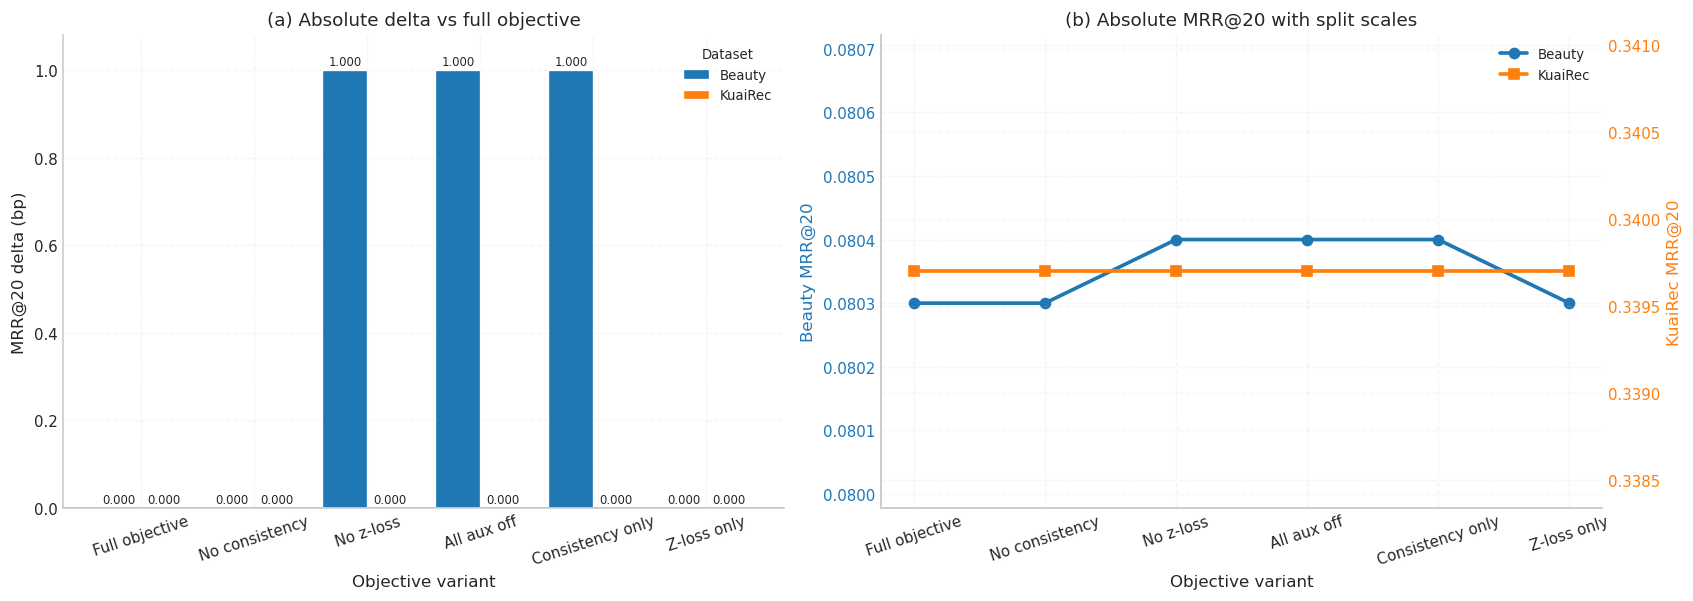

### 활용 포인트

이 그림의 핵심은 regularizer를 과대해석하지 않는 것이다. 실제 선택된 base에서는 objective 일부를 꺼도 변화가 수 bp 수준에 머물러, 큰 성능 차이는 auxiliary term보다 routing/stage 설계에서 온다고 보는 편이 맞다. 논문에서는 이 그림을 본문보다 appendix 성격의 sanity check로 두고, main contribution은 routing control과 stage structure figure로 밀어주는 구성이 더 설득력 있다.

In [14]:
OBJECTIVE_SUMMARY_PATHS = [
    ABLATION_LOG_ROOT / "ablation_dualset_core_global_queue_v1_first_primary/beauty/summary.csv",
    ABLATION_LOG_ROOT / "ablation_dualset_core_global_queue_v1_first_primary/KuaiRecLargeStrictPosV2_0.2/summary.csv",
]
OBJECTIVE_VARIANT_ORDER = [
    "BASE_REPLAY",
    "NO_CONSISTENCY",
    "NO_ZLOSS",
    "ALL_AUX_OFF",
    "CONSISTENCY_ONLY",
    "ZLOSS_ONLY",
]
OBJECTIVE_LABELS = {
    "BASE_REPLAY": "Full objective",
    "NO_CONSISTENCY": "No consistency",
    "NO_ZLOSS": "No z-loss",
    "ALL_AUX_OFF": "All aux off",
    "CONSISTENCY_ONLY": "Consistency only",
    "ZLOSS_ONLY": "Z-loss only",
}
OBJECTIVE_DATASET_LABELS = {
    "beauty": "Beauty",
    "KuaiRecLargeStrictPosV2_0.2": "KuaiRec",
}


def demo_objective_actual():
    rows = pd.DataFrame([
        {"dataset": "Beauty", "setting_key": "BASE_REPLAY", "test_mrr20": 0.0803},
        {"dataset": "Beauty", "setting_key": "NO_CONSISTENCY", "test_mrr20": 0.0803},
        {"dataset": "Beauty", "setting_key": "NO_ZLOSS", "test_mrr20": 0.0804},
        {"dataset": "Beauty", "setting_key": "ALL_AUX_OFF", "test_mrr20": 0.0804},
        {"dataset": "Beauty", "setting_key": "CONSISTENCY_ONLY", "test_mrr20": 0.0804},
        {"dataset": "Beauty", "setting_key": "ZLOSS_ONLY", "test_mrr20": 0.0803},
        {"dataset": "KuaiRec", "setting_key": "BASE_REPLAY", "test_mrr20": 0.3397},
        {"dataset": "KuaiRec", "setting_key": "NO_CONSISTENCY", "test_mrr20": 0.3397},
        {"dataset": "KuaiRec", "setting_key": "NO_ZLOSS", "test_mrr20": 0.3397},
        {"dataset": "KuaiRec", "setting_key": "ALL_AUX_OFF", "test_mrr20": 0.3397},
        {"dataset": "KuaiRec", "setting_key": "CONSISTENCY_ONLY", "test_mrr20": 0.3397},
        {"dataset": "KuaiRec", "setting_key": "ZLOSS_ONLY", "test_mrr20": 0.3397},
    ])
    baseline = rows[rows["setting_key"] == "BASE_REPLAY"][["dataset", "test_mrr20"]].rename(columns={"test_mrr20": "baseline_mrr20"})
    rows = rows.merge(baseline, on="dataset", how="left")
    rows["delta_bp"] = (rows["test_mrr20"] - rows["baseline_mrr20"]) * 10000.0
    rows["variant"] = rows["setting_key"].map(OBJECTIVE_LABELS)
    return rows


def load_objective_actual():
    objective_df, objective_mode = load_ablation_summary(
        OBJECTIVE_SUMMARY_PATHS,
        allowed_stages=["objective_variants", "baseline_pool"],
        allowed_keys=OBJECTIVE_VARIANT_ORDER,
    )
    if objective_df.empty:
        return demo_objective_actual(), "demo"

    grouped = (
        objective_df.groupby(["dataset", "setting_key"], as_index=False)
        .agg(test_mrr20=("test_mrr20", "median"), seed_count=("seed_id", "nunique"), setting_detail=("setting_detail", "first"))
    )
    grouped["dataset"] = grouped["dataset"].map(OBJECTIVE_DATASET_LABELS).fillna(grouped["dataset"])
    baseline = grouped[grouped["setting_key"] == "BASE_REPLAY"][["dataset", "test_mrr20"]].rename(columns={"test_mrr20": "baseline_mrr20"})
    grouped = grouped.merge(baseline, on="dataset", how="left")
    grouped["delta_bp"] = (grouped["test_mrr20"] - grouped["baseline_mrr20"]) * 10000.0
    grouped["variant"] = grouped["setting_key"].map(OBJECTIVE_LABELS).fillna(grouped["setting_key"])
    return grouped, "summary"


objective_plot_df, objective_mode = load_objective_actual()
objective_plot_df["variant"] = pd.Categorical(
    objective_plot_df["variant"],
    categories=[OBJECTIVE_LABELS[key] for key in OBJECTIVE_VARIANT_ORDER],
    ordered=True,
)
objective_plot_df = objective_plot_df.sort_values(["dataset", "variant"])
show_data_badge({"objective_variants": objective_mode}, "Objective robustness comparison uses first-primary ablation summary when available.")

fig, axes = plt.subplots(1, 2, figsize=(14.0, 4.9), constrained_layout=True)
grouped_barplot(
    objective_plot_df,
    x="variant",
    hue="dataset",
    y="delta_bp",
    ax=axes[0],
    title="(a) Absolute delta vs full objective",
    ylabel="MRR@20 delta (bp)",
    xlabel="Objective variant",
    rotate=18,
    zero_base=False,
    legend_title="Dataset",
)
axes[0].axhline(0.0, color="#94a3b8", linewidth=1.0)
_apply_tight_ylim(axes[0], objective_plot_df["delta_bp"].tolist(), zero_base=False)

variant_order = [OBJECTIVE_LABELS[key] for key in OBJECTIVE_VARIANT_ORDER]
dataset_order = [dataset for dataset in ["Beauty", "KuaiRec"] if dataset in objective_plot_df["dataset"].unique()]
line_colors = _color_map(dataset_order)
axes[1].set_xticks(np.arange(len(variant_order)))
axes[1].set_xticklabels(variant_order, rotation=18)
axes[1].set_title("(b) Absolute MRR@20 with split scales")
axes[1].set_xlabel("Objective variant")
left_dataset = dataset_order[0] if dataset_order else None
right_dataset = dataset_order[1] if len(dataset_order) > 1 else None
if left_dataset is not None:
    left_df = objective_plot_df[objective_plot_df["dataset"] == left_dataset]
    left_y = [float(left_df[left_df["variant"] == variant]["test_mrr20"].iloc[0]) if not left_df[left_df["variant"] == variant].empty else np.nan for variant in variant_order]
    axes[1].plot(np.arange(len(variant_order)), left_y, marker="o", linewidth=2.2, color=line_colors[left_dataset], label=left_dataset)
    axes[1].set_ylabel(f"{left_dataset} MRR@20", color=line_colors[left_dataset])
    axes[1].tick_params(axis="y", labelcolor=line_colors[left_dataset])
    _apply_tight_ylim(axes[1], [item for item in left_y if pd.notna(item)], zero_base=False)
if right_dataset is not None:
    ax_right = axes[1].twinx()
    right_df = objective_plot_df[objective_plot_df["dataset"] == right_dataset]
    right_y = [float(right_df[right_df["variant"] == variant]["test_mrr20"].iloc[0]) if not right_df[right_df["variant"] == variant].empty else np.nan for variant in variant_order]
    ax_right.plot(np.arange(len(variant_order)), right_y, marker="s", linewidth=2.2, color=line_colors[right_dataset], label=right_dataset)
    ax_right.set_ylabel(f"{right_dataset} MRR@20", color=line_colors[right_dataset])
    ax_right.tick_params(axis="y", labelcolor=line_colors[right_dataset])
    _apply_tight_ylim(ax_right, [item for item in right_y if pd.notna(item)], zero_base=False)
    legend_handles = [
        Line2D([0], [0], color=line_colors[left_dataset], marker="o", linewidth=2.2, label=left_dataset),
        Line2D([0], [0], color=line_colors[right_dataset], marker="s", linewidth=2.2, label=right_dataset),
    ]
    axes[1].legend(handles=legend_handles, frameon=False, loc="upper right")

saved_paths = export_figure(fig, "00_storyboard_objective_sanity", RESULTS_ROOT)
display(Markdown("Saved figures: " + ", ".join(str(path) for path in saved_paths)))
plt.show()

story_note(
    "활용 포인트",
    "이 그림의 핵심은 regularizer를 과대해석하지 않는 것이다. 실제 선택된 base에서는 objective 일부를 꺼도 변화가 수 bp 수준에 머물러, 큰 성능 차이는 auxiliary term보다 routing/stage 설계에서 온다고 보는 편이 맞다. 논문에서는 이 그림을 본문보다 appendix 성격의 sanity check로 두고, main contribution은 routing control과 stage structure figure로 밀어주는 구성이 더 설득력 있다."
)


## 4. Diagnostics: Structured Routing, Not Collapse

이 섹션은 routing이 단순히 sparse하기만 한 것이 아니라, 실제로 구조적이고 일관된 partition을 만든다는 점을 보여주기 위한 진단 그림이다.

- `cv_usage`와 KNN consistency를 함께 보면, expert usage가 불균형해지지 않으면서도 route partition은 안정적인지 볼 수 있다.
- `top1_max_frac`와 entropy를 함께 보면, 특정 expert 독점 없이 분산된 routing인지 확인할 수 있다.
- feature-family consistency를 stage별로 보면, 어느 stage가 어떤 cue를 더 안정적으로 분리하는지 설명할 수 있다.

아래 그림은 실제 `trial_summary.csv`와 `test_diag.json`을 우선 사용하고, 없을 때만 fallback을 사용한다.


<div style='padding:10px 14px;border-radius:10px;border:2px solid #166534;background:#f0fdf4;color:#166534;font-weight:800;display:inline-block;letter-spacing:0.02em'>REAL EXPERIMENT DATA</div><div style='margin-top:8px;color:#334155;font-size:13px;line-height:1.45'>Diagnostic scatter is built from actual stage-structure result JSONs when available; each point uses the stage metric exposed by that run.</div>

Saved figures: /workspace/FeaturedMoE/writing/results/generated_figures/00_storyboard_diagnostics.png, /workspace/FeaturedMoE/writing/results/generated_figures/00_storyboard_diagnostics.pdf

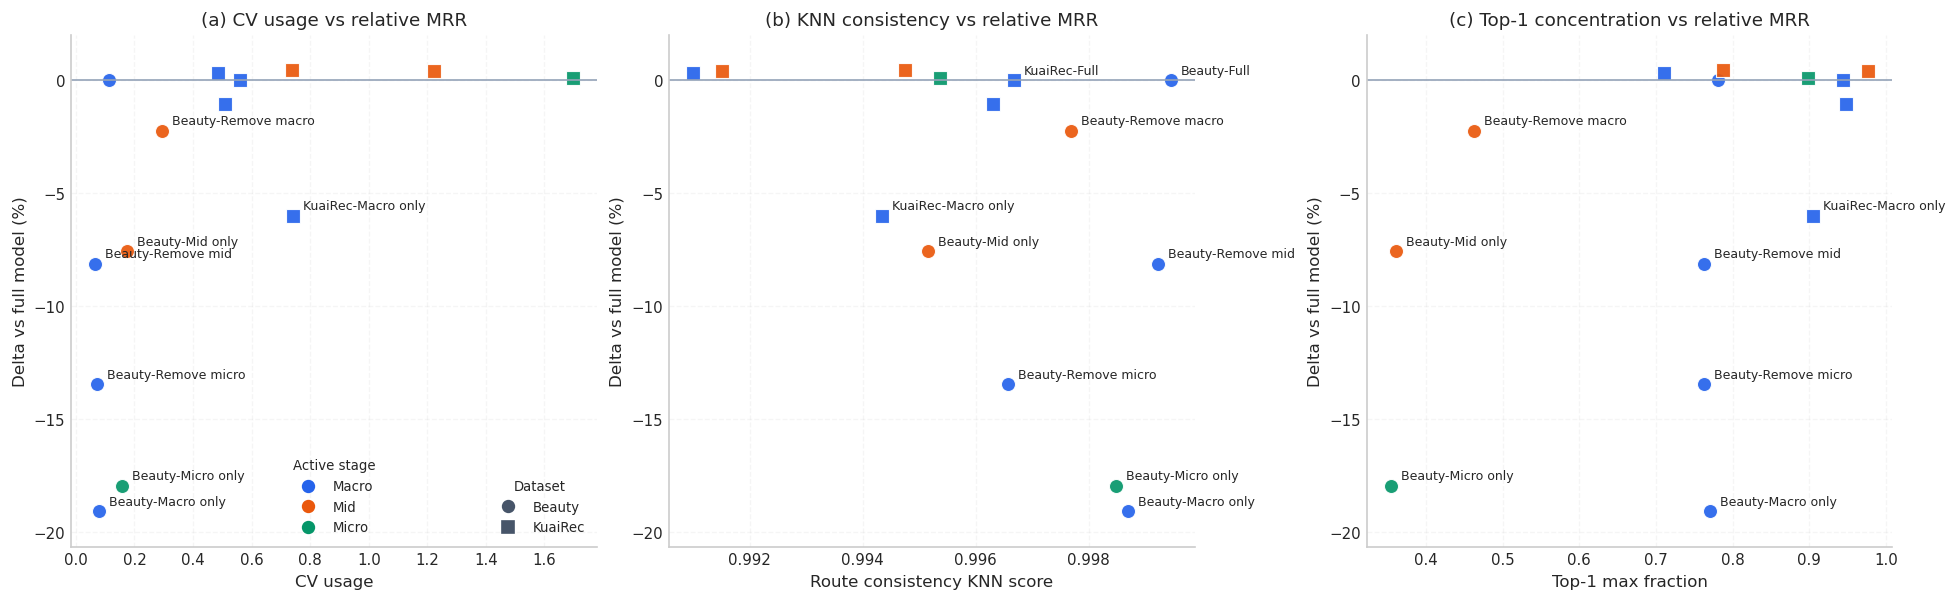

### 활용 포인트

이 그림은 성능 저하가 단순히 MoE block을 빼서 생긴 것이 아니라, routing 통계가 어떻게 무너졌는지와 연결된다는 점을 보여준다. 데이터셋마다 절대 MRR 스케일이 다르기 때문에 y축은 full model 대비 상대 변화로 맞췄고, 각 점은 해당 ablation run에서 실제로 노출된 active stage metric을 사용했다. 본문에서는 cv_usage, KNN consistency, top-1 concentration이 동시에 움직이는 방향을 보여주면서, 좋은 routing은 단순 sparsity가 아니라 성능과 함께 유지되는 구조적 partition이라는 식으로 설명하면 된다.

In [15]:
import re

BASE_RESULT_PATHS = {
    "Beauty": Path("/workspace/FeaturedMoE/experiments/run/artifacts/results/fmoe_n4/beauty_FeaturedMoE_N3_p4xd_xd_beauty_b25_lr_h8_seen_anchor_s1_20260416_030201_046233_pid244350.json"),
    "KuaiRec": Path("/workspace/FeaturedMoE/experiments/run/artifacts/results/fmoe_n4/KuaiRecLargeStrictPosV2_0.2_FeaturedMoE_N3_p4s3_s3_kuaireclargestrictposv2_0_2_s02_h14_seen_hi_s1_20260415_081315_824627_pid124072.json"),
}
STAGE_RESULT_DIRS = {
    "Beauty": Path("/workspace/FeaturedMoE/experiments/run/artifacts/results/fmoe_n4/normal/ablation_dualset_core_global_queue_v1_first_primary/P4B/beauty/FMoEN3"),
    "KuaiRec": Path("/workspace/FeaturedMoE/experiments/run/artifacts/results/fmoe_n4/normal/ablation_dualset_core_global_queue_v1_first_primary/P4B/KuaiRecLargeStrictPosV2_0.2/FMoEN3"),
}
VARIANT_PATTERNS = {
    "Full": None,
    "Remove macro": "st_01",
    "Remove mid": "st_02",
    "Remove micro": "st_03",
    "Macro only": "st_04",
    "Mid only": "st_05",
    "Micro only": "st_06",
}
STAGE_PREFIXES = [("macro_1", "Macro"), ("mid_1", "Mid"), ("micro_1", "Micro")]
STAGE_COLORS = {"Macro": "#2563eb", "Mid": "#ea580c", "Micro": "#059669"}
DATASET_MARKERS = {"Beauty": "o", "KuaiRec": "s"}


def extract_numeric_metric(raw_text: str, key: str):
    match = re.search(r'"' + re.escape(key) + r'"\s*:\s*([-+0-9.eE]+)', raw_text)
    return float(match.group(1)) if match else None


def collect_stage_diag_rows(result_path: Path, dataset_label: str, variant_label: str):
    if not result_path.exists():
        return []
    raw_text = result_path.read_text()
    test_mrr20 = extract_numeric_metric(raw_text, "test_mrr@20")
    if test_mrr20 is None:
        return []
    rows = []
    for prefix, stage_name in STAGE_PREFIXES:
        cv_usage = extract_numeric_metric(raw_text, f"{prefix}.cv_usage")
        knn_consistency = extract_numeric_metric(raw_text, f"{prefix}.route_consistency_knn_score")
        top1_max_frac = extract_numeric_metric(raw_text, f"{prefix}.top1_max_frac")
        entropy_mean = extract_numeric_metric(raw_text, f"{prefix}.entropy_mean")
        if any(value is None for value in [cv_usage, knn_consistency, top1_max_frac, entropy_mean]):
            continue
        rows.append({
            "dataset": dataset_label,
            "variant": variant_label,
            "stage": stage_name,
            "test_mrr20": float(test_mrr20),
            "cv_usage": float(cv_usage),
            "knn_consistency": float(knn_consistency),
            "top1_max_frac": float(top1_max_frac),
            "entropy_mean": float(entropy_mean),
            "label": f"{dataset_label}-{variant_label}",
        })
    return rows


def load_diag_performance_rows():
    rows = []
    for dataset_label, base_path in BASE_RESULT_PATHS.items():
        rows.extend(collect_stage_diag_rows(base_path, dataset_label, "Full"))
    for dataset_label, result_dir in STAGE_RESULT_DIRS.items():
        for variant_label, pattern in VARIANT_PATTERNS.items():
            if pattern is None:
                continue
            matches = sorted(result_dir.glob(f"*_{pattern}_s1_*.json"))
            if not matches:
                continue
            rows.extend(collect_stage_diag_rows(matches[0], dataset_label, variant_label))
    diag_df = pd.DataFrame(rows)
    if not diag_df.empty:
        base_df = diag_df[diag_df["variant"].eq("Full")][["dataset", "test_mrr20"]].rename(columns={"test_mrr20": "base_mrr20"})
        diag_df = diag_df.merge(base_df, on="dataset", how="left")
        diag_df["delta_vs_base_pct"] = (diag_df["test_mrr20"] / diag_df["base_mrr20"] - 1.0) * 100.0
        return diag_df, "result_json"

    demo_df = pd.DataFrame([
        {"dataset": "Beauty", "variant": "Full", "stage": "Macro", "test_mrr20": 0.0713, "cv_usage": 0.114, "knn_consistency": 0.9994, "top1_max_frac": 0.198, "entropy_mean": 2.42},
        {"dataset": "Beauty", "variant": "Remove macro", "stage": "Mid", "test_mrr20": 0.0689, "cv_usage": 0.293, "knn_consistency": 0.9950, "top1_max_frac": 0.487, "entropy_mean": 1.87},
        {"dataset": "Beauty", "variant": "Remove mid", "stage": "Macro", "test_mrr20": 0.0615, "cv_usage": 0.065, "knn_consistency": 0.9936, "top1_max_frac": 0.244, "entropy_mean": 2.05},
        {"dataset": "Beauty", "variant": "Mid only", "stage": "Mid", "test_mrr20": 0.0660, "cv_usage": 0.173, "knn_consistency": 0.9952, "top1_max_frac": 0.361, "entropy_mean": 1.94},
        {"dataset": "KuaiRec", "variant": "Full", "stage": "Macro", "test_mrr20": 0.3397, "cv_usage": 0.560, "knn_consistency": 0.9967, "top1_max_frac": 0.563, "entropy_mean": 2.16},
        {"dataset": "KuaiRec", "variant": "Remove macro", "stage": "Mid", "test_mrr20": 0.3412, "cv_usage": 0.737, "knn_consistency": 0.9976, "top1_max_frac": 0.686, "entropy_mean": 1.78},
        {"dataset": "KuaiRec", "variant": "Mid only", "stage": "Mid", "test_mrr20": 0.3407, "cv_usage": 1.222, "knn_consistency": 0.9962, "top1_max_frac": 0.774, "entropy_mean": 1.63},
        {"dataset": "KuaiRec", "variant": "Micro only", "stage": "Micro", "test_mrr20": 0.3405, "cv_usage": 1.697, "knn_consistency": 0.9958, "top1_max_frac": 0.904, "entropy_mean": 1.22},
    ])
    base_df = demo_df[demo_df["variant"].eq("Full")][["dataset", "test_mrr20"]].rename(columns={"test_mrr20": "base_mrr20"})
    demo_df = demo_df.merge(base_df, on="dataset", how="left")
    demo_df["delta_vs_base_pct"] = (demo_df["test_mrr20"] / demo_df["base_mrr20"] - 1.0) * 100.0
    demo_df["label"] = demo_df["dataset"] + "-" + demo_df["variant"]
    return demo_df, "demo"


diag_df, diag_mode = load_diag_performance_rows()
show_data_badge(
    {"diag_scatter": diag_mode},
    "Diagnostic scatter is built from actual stage-structure result JSONs when available; each point uses the stage metric exposed by that run.",
)

fig, axes = plt.subplots(1, 3, figsize=(16.2, 4.9), constrained_layout=True)
scatter_specs = [
    ("cv_usage", "(a) CV usage vs relative MRR", "CV usage"),
    ("knn_consistency", "(b) KNN consistency vs relative MRR", "Route consistency KNN score"),
    ("top1_max_frac", "(c) Top-1 concentration vs relative MRR", "Top-1 max fraction"),
]
for ax, (metric_key, title, xlabel) in zip(axes, scatter_specs):
    for _, row in diag_df.iterrows():
        ax.scatter(
            row[metric_key],
            row["delta_vs_base_pct"],
            s=72,
            color=STAGE_COLORS.get(row["stage"], "#334155"),
            marker=DATASET_MARKERS.get(row["dataset"], "o"),
            alpha=0.92,
            edgecolors="white",
            linewidths=0.7,
        )
        should_annotate = abs(row["delta_vs_base_pct"]) >= 2.0 or (metric_key == "knn_consistency" and row["variant"] == "Full")
        if should_annotate:
            ax.annotate(row["label"], (row[metric_key], row["delta_vs_base_pct"]), xytext=(6, 4), textcoords="offset points", fontsize=7.5)
    ax.axhline(0.0, color="#94a3b8", linewidth=1.0)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Delta vs full model (%)")
    _apply_tight_ylim(ax, diag_df["delta_vs_base_pct"].tolist(), zero_base=False)

dataset_handles = [
    Line2D([0], [0], marker=DATASET_MARKERS[name], color="#475569", linestyle="None", markersize=7, label=name)
    for name in diag_df["dataset"].drop_duplicates().tolist()
]
stage_handles = [
    Line2D([0], [0], marker="o", color=STAGE_COLORS[name], linestyle="None", markersize=7, label=name)
    for name in ["Macro", "Mid", "Micro"]
    if name in diag_df["stage"].unique()
]
legend_datasets = axes[0].legend(handles=dataset_handles, frameon=False, loc="lower right", title="Dataset")
axes[0].add_artist(legend_datasets)
axes[0].legend(handles=stage_handles, frameon=False, loc="lower center", title="Active stage")

saved_paths = export_figure(fig, "00_storyboard_diagnostics", RESULTS_ROOT)
display(Markdown("Saved figures: " + ", ".join(str(path) for path in saved_paths)))
plt.show()

story_note(
    "활용 포인트",
    "이 그림은 성능 저하가 단순히 MoE block을 빼서 생긴 것이 아니라, routing 통계가 어떻게 무너졌는지와 연결된다는 점을 보여준다. 데이터셋마다 절대 MRR 스케일이 다르기 때문에 y축은 full model 대비 상대 변화로 맞췄고, 각 점은 해당 ablation run에서 실제로 노출된 active stage metric을 사용했다. 본문에서는 cv_usage, KNN consistency, top-1 concentration이 동시에 움직이는 방향을 보여주면서, 좋은 routing은 단순 sparsity가 아니라 성능과 함께 유지되는 구조적 partition이라는 식으로 설명하면 된다."
)


## 5. Cross-Dataset Slice Atlas

A single aggregate MRR number still hides whether the model survives the difficult regimes that reviewers usually ask about.

This section now uses the best available real special-metric artifact for each dataset and emphasizes three questions:

- how large the seen-to-unseen target gap is,
- how quickly quality collapses from hot to cold targets,
- whether the model keeps any retention on short sessions.

The plots are normalized where needed so very different dataset scales can still be compared in one figure.

<div style='padding:10px 14px;border-radius:10px;border:2px solid #166534;background:#f0fdf4;color:#166534;font-weight:800;display:inline-block;letter-spacing:0.02em'>REAL EXPERIMENT DATA</div><div style='margin-top:8px;color:#334155;font-size:13px;line-height:1.45'>cross-dataset slice atlas는 dataset별 best_valid special metrics를 직접 읽고, popularity/session 패널만 데이터셋 내부 peak 기준으로 정규화했습니다.</div>

,dataset,overall,seen,unseen,unseen_retention_pct
0,RetailRocket,0.3355,0.3745,0.0078,2.0819
1,LastFM,0.2765,0.3202,0.0000,0.0000
2,Foursquare,0.1859,0.2517,0.0002,0.0838
3,ML-1M,0.0979,0.0980,0.0000,0.0000
4,Beauty,0.0731,0.0920,0.0000,0.0000
5,KuaiRec,0.0158,0.0209,0.0000,0.0000


Saved figures: /workspace/FeaturedMoE/writing/results/generated_figures/00_storyboard_slice_atlas.png, /workspace/FeaturedMoE/writing/results/generated_figures/00_storyboard_slice_atlas.pdf

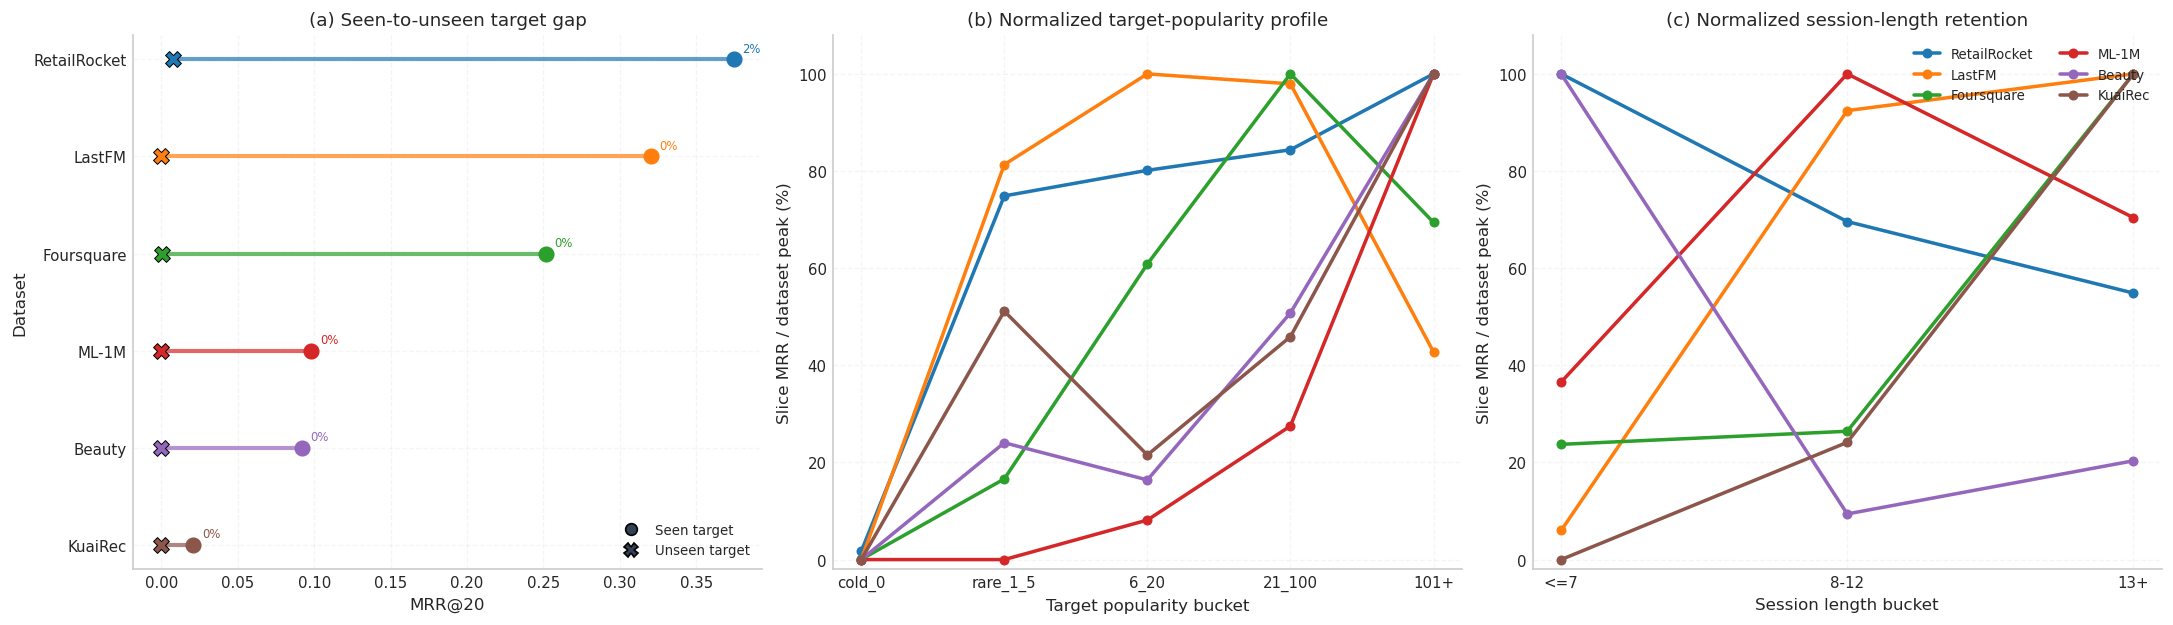

### 활용 포인트

이 그림은 평균 MRR만으로는 보이지 않는 취약 구간을 dataset 단위로 동시에 보여준다. 왼쪽 패널은 seen 대비 unseen target 붕괴 정도를 직접 드러내고, 가운데와 오른쪽 패널은 절대 스케일이 다른 데이터셋도 내부 peak 대비 retention으로 비교하게 만든다. 본문보다 appendix에 더 잘 맞지만, reviewer가 cold target과 short session 쪽 robustness를 물을 때 바로 대응할 수 있는 그림이다.

In [16]:
SPECIAL_ROOT_CANDIDATES = [
    Path("/workspace/FeaturedMoE/experiments/run/artifacts/results/fmoe_full/special/fullhistory_portfolio8/FH1"),
    Path("/workspace/FeaturedMoE/experiments/run/artifacts/results/fmoe_n4/special/fullhistory_portfolio8/FH1"),
]
SLICE_DATASET_LABELS = {
    "KuaiRecLargeStrictPosV2_0.2": "KuaiRec",
    "beauty": "Beauty",
    "foursquare": "Foursquare",
    "lastfm0.03": "LastFM",
    "movielens1m": "ML-1M",
    "retail_rocket": "RetailRocket",
}
POPULARITY_ORDER = ["cold_0", "rare_1_5", "6_20", "21_100", "101+"]
SESSION_ORDER = ["<=7", "8-12", "13+"]


def _find_bucket(payload_dict, aliases):
    for alias in aliases:
        if alias in payload_dict:
            return payload_dict[alias]
    return None


def _safe_ratio(numerator, denominator):
    if denominator is None or denominator == 0:
        return 0.0
    return float(numerator) / float(denominator)


def load_cross_dataset_slice_profiles(roots):
    dataset_best = {}
    popularity_alias = {
        "cold_0": ["cold_0", "<=5"],
        "rare_1_5": ["rare_1_5"],
        "6_20": ["6_20", "6-20"],
        "21_100": ["21_100", "21-100"],
        "101+": ["101+", ">100"],
    }
    session_alias = {
        "<=7": ["<=7", "1-2"],
        "8-12": ["8-12", "3-5"],
        "13+": ["13+", "6+"],
    }

    for root in roots:
        if not root.exists():
            continue
        for dataset_dir in sorted(root.iterdir()):
            model_dir = dataset_dir / "FMoEN3"
            if not model_dir.exists():
                continue
            dataset = dataset_dir.name
            for path in sorted(model_dir.glob("*_special_metrics.json")):
                payload = json.loads(path.read_text())
                special = payload.get("best_valid_special_metrics", {})
                seen_mrr = special.get("overall_seen_target", {}).get("mrr@20")
                overall_mrr = special.get("overall", {}).get("mrr@20")
                selection_score = seen_mrr if seen_mrr is not None else overall_mrr
                if selection_score is None:
                    continue
                candidate = {
                    "dataset": dataset,
                    "dataset_label": SLICE_DATASET_LABELS.get(dataset, dataset),
                    "selection_score": float(selection_score),
                    "payload": payload,
                    "path": path,
                }
                current = dataset_best.get(dataset)
                if current is None or candidate["selection_score"] > current["selection_score"]:
                    dataset_best[dataset] = candidate

    summary_rows = []
    popularity_rows = []
    session_rows = []
    for dataset, best in sorted(dataset_best.items(), key=lambda item: item[1]["selection_score"], reverse=True):
        special = best["payload"].get("best_valid_special_metrics", {})
        slices = special.get("slices", {})
        overall_mrr = float(special.get("overall", {}).get("mrr@20", 0.0) or 0.0)
        seen_mrr = float(special.get("overall_seen_target", {}).get("mrr@20", 0.0) or 0.0)
        unseen_mrr = float(special.get("overall_unseen_target", {}).get("mrr@20", 0.0) or 0.0)
        seen_count = int(special.get("overall_seen_target", {}).get("count", 0) or 0)
        unseen_count = int(special.get("overall_unseen_target", {}).get("count", 0) or 0)
        summary_rows.append({
            "dataset": dataset,
            "dataset_label": best["dataset_label"],
            "overall_mrr20": overall_mrr,
            "seen_mrr20": seen_mrr,
            "unseen_mrr20": unseen_mrr,
            "seen_count": seen_count,
            "unseen_count": unseen_count,
            "unseen_retention_pct": _safe_ratio(unseen_mrr, seen_mrr) * 100.0,
            "source_path": str(best["path"]),
        })

        popularity = slices.get("target_popularity_abs", {}) or slices.get("target_popularity_abs_legacy", {})
        for bucket in POPULARITY_ORDER:
            bucket_payload = _find_bucket(popularity, popularity_alias[bucket])
            if bucket_payload is None:
                continue
            popularity_rows.append({
                "dataset": dataset,
                "dataset_label": best["dataset_label"],
                "bucket": bucket,
                "mrr20": float(bucket_payload.get("mrr@20", 0.0) or 0.0),
                "count": int(bucket_payload.get("count", 0) or 0),
            })

        session_len = slices.get("session_len", {}) or slices.get("session_len_legacy", {})
        for bucket in SESSION_ORDER:
            bucket_payload = _find_bucket(session_len, session_alias[bucket])
            if bucket_payload is None:
                continue
            session_rows.append({
                "dataset": dataset,
                "dataset_label": best["dataset_label"],
                "session_bucket": bucket,
                "mrr20": float(bucket_payload.get("mrr@20", 0.0) or 0.0),
                "count": int(bucket_payload.get("count", 0) or 0),
            })

    summary_df = pd.DataFrame(summary_rows)
    popularity_df = pd.DataFrame(popularity_rows)
    session_df = pd.DataFrame(session_rows)

    if not summary_df.empty:
        popularity_df["bucket"] = pd.Categorical(popularity_df["bucket"], categories=POPULARITY_ORDER, ordered=True)
        popularity_df = popularity_df.sort_values(["dataset_label", "bucket"])
        pop_peak = popularity_df.groupby("dataset_label")["mrr20"].transform("max")
        popularity_df["retention_pct"] = np.where(pop_peak > 0, popularity_df["mrr20"] / pop_peak * 100.0, 0.0)

        session_df["session_bucket"] = pd.Categorical(session_df["session_bucket"], categories=SESSION_ORDER, ordered=True)
        session_df = session_df.sort_values(["dataset_label", "session_bucket"])
        session_peak = session_df.groupby("dataset_label")["mrr20"].transform("max")
        session_df["retention_pct"] = np.where(session_peak > 0, session_df["mrr20"] / session_peak * 100.0, 0.0)
        return summary_df, popularity_df, session_df, "json"

    summary_df = pd.DataFrame([
        {"dataset": "retail_rocket", "dataset_label": "RetailRocket", "overall_mrr20": 0.335, "seen_mrr20": 0.374, "unseen_mrr20": 0.008, "seen_count": 3100, "unseen_count": 410, "unseen_retention_pct": 2.1, "source_path": "demo"},
        {"dataset": "lastfm0.03", "dataset_label": "LastFM", "overall_mrr20": 0.277, "seen_mrr20": 0.320, "unseen_mrr20": 0.000, "seen_count": 3482, "unseen_count": 491, "unseen_retention_pct": 0.0, "source_path": "demo"},
        {"dataset": "foursquare", "dataset_label": "Foursquare", "overall_mrr20": 0.186, "seen_mrr20": 0.252, "unseen_mrr20": 0.0002, "seen_count": 2200, "unseen_count": 500, "unseen_retention_pct": 0.1, "source_path": "demo"},
    ])
    popularity_df = pd.DataFrame([
        {"dataset": "retail_rocket", "dataset_label": "RetailRocket", "bucket": "cold_0", "mrr20": 0.008, "count": 410, "retention_pct": 1.7},
        {"dataset": "retail_rocket", "dataset_label": "RetailRocket", "bucket": "rare_1_5", "mrr20": 0.343, "count": 1330, "retention_pct": 74.9},
        {"dataset": "retail_rocket", "dataset_label": "RetailRocket", "bucket": "6_20", "mrr20": 0.368, "count": 980, "retention_pct": 80.1},
        {"dataset": "retail_rocket", "dataset_label": "RetailRocket", "bucket": "21_100", "mrr20": 0.387, "count": 520, "retention_pct": 84.4},
        {"dataset": "retail_rocket", "dataset_label": "RetailRocket", "bucket": "101+", "mrr20": 0.459, "count": 60, "retention_pct": 100.0},
        {"dataset": "lastfm0.03", "dataset_label": "LastFM", "bucket": "cold_0", "mrr20": 0.000, "count": 491, "retention_pct": 0.0},
        {"dataset": "lastfm0.03", "dataset_label": "LastFM", "bucket": "rare_1_5", "mrr20": 0.288, "count": 1462, "retention_pct": 81.3},
        {"dataset": "lastfm0.03", "dataset_label": "LastFM", "bucket": "6_20", "mrr20": 0.354, "count": 1086, "retention_pct": 100.0},
        {"dataset": "lastfm0.03", "dataset_label": "LastFM", "bucket": "21_100", "mrr20": 0.347, "count": 534, "retention_pct": 98.0},
        {"dataset": "lastfm0.03", "dataset_label": "LastFM", "bucket": "101+", "mrr20": 0.151, "count": 26, "retention_pct": 42.8},
        {"dataset": "foursquare", "dataset_label": "Foursquare", "bucket": "cold_0", "mrr20": 0.0002, "count": 520, "retention_pct": 0.0},
        {"dataset": "foursquare", "dataset_label": "Foursquare", "bucket": "rare_1_5", "mrr20": 0.082, "count": 880, "retention_pct": 16.7},
        {"dataset": "foursquare", "dataset_label": "Foursquare", "bucket": "6_20", "mrr20": 0.299, "count": 680, "retention_pct": 60.8},
        {"dataset": "foursquare", "dataset_label": "Foursquare", "bucket": "21_100", "mrr20": 0.491, "count": 440, "retention_pct": 100.0},
        {"dataset": "foursquare", "dataset_label": "Foursquare", "bucket": "101+", "mrr20": 0.341, "count": 180, "retention_pct": 69.4},
    ])
    session_df = pd.DataFrame([
        {"dataset": "retail_rocket", "dataset_label": "RetailRocket", "session_bucket": "<=7", "mrr20": 0.356, "count": 120, "retention_pct": 100.0},
        {"dataset": "retail_rocket", "dataset_label": "RetailRocket", "session_bucket": "8-12", "mrr20": 0.248, "count": 460, "retention_pct": 69.6},
        {"dataset": "retail_rocket", "dataset_label": "RetailRocket", "session_bucket": "13+", "mrr20": 0.196, "count": 2980, "retention_pct": 54.9},
        {"dataset": "lastfm0.03", "dataset_label": "LastFM", "session_bucket": "<=7", "mrr20": 0.017, "count": 73, "retention_pct": 6.0},
        {"dataset": "lastfm0.03", "dataset_label": "LastFM", "session_bucket": "8-12", "mrr20": 0.261, "count": 44, "retention_pct": 92.4},
        {"dataset": "lastfm0.03", "dataset_label": "LastFM", "session_bucket": "13+", "mrr20": 0.282, "count": 3482, "retention_pct": 100.0},
        {"dataset": "foursquare", "dataset_label": "Foursquare", "session_bucket": "<=7", "mrr20": 0.048, "count": 110, "retention_pct": 23.7},
        {"dataset": "foursquare", "dataset_label": "Foursquare", "session_bucket": "8-12", "mrr20": 0.054, "count": 320, "retention_pct": 26.4},
        {"dataset": "foursquare", "dataset_label": "Foursquare", "session_bucket": "13+", "mrr20": 0.203, "count": 2280, "retention_pct": 100.0},
    ])
    return summary_df, popularity_df, session_df, "demo"


slice_summary_df, slice_popularity_df, slice_session_df, slice_mode = load_cross_dataset_slice_profiles(SPECIAL_ROOT_CANDIDATES)
slice_summary_df = slice_summary_df.sort_values("seen_mrr20", ascending=False).reset_index(drop=True)
show_data_badge({"slice_atlas": slice_mode}, "cross-dataset slice atlas는 dataset별 best_valid special metrics를 직접 읽고, popularity/session 패널만 데이터셋 내부 peak 기준으로 정규화했습니다.")
display(
    slice_summary_df[["dataset_label", "overall_mrr20", "seen_mrr20", "unseen_mrr20", "unseen_retention_pct"]]
    .rename(columns={"dataset_label": "dataset", "overall_mrr20": "overall", "seen_mrr20": "seen", "unseen_mrr20": "unseen", "unseen_retention_pct": "unseen_retention_pct"})
    .round(4)
)

fig, axes = plt.subplots(1, 3, figsize=(18.0, 5.1), constrained_layout=True)
dataset_order = slice_summary_df["dataset_label"].tolist()
colors = _color_map(dataset_order)

plot_df = slice_summary_df.sort_values("seen_mrr20", ascending=True).reset_index(drop=True)
y_positions = np.arange(len(plot_df))
max_seen = float(plot_df["seen_mrr20"].max() or 0.0)
label_pad = 0.015 * max_seen if max_seen > 0 else 0.002
for idx, row in plot_df.iterrows():
    color = colors[row["dataset_label"]]
    axes[0].hlines(idx, row["unseen_mrr20"], row["seen_mrr20"], color=color, linewidth=2.5, alpha=0.70)
    axes[0].scatter(row["seen_mrr20"], idx, s=75, color=color, marker="o", zorder=3)
    axes[0].scatter(row["unseen_mrr20"], idx, s=90, color=color, marker="X", edgecolor="black", linewidth=0.6, zorder=4)
    axes[0].text(row["seen_mrr20"] + label_pad, idx + 0.08, f"{row['unseen_retention_pct']:.0f}%", fontsize=7, color=color)
axes[0].set_yticks(y_positions)
axes[0].set_yticklabels(plot_df["dataset_label"])
axes[0].set_title("(a) Seen-to-unseen target gap")
axes[0].set_xlabel("MRR@20")
axes[0].set_ylabel("Dataset")
axes[0].grid(axis="x", alpha=0.20)
seen_handle = Line2D([0], [0], marker="o", color="none", markerfacecolor="#334155", markersize=7, label="Seen target")
unseen_handle = Line2D([0], [0], marker="X", color="none", markerfacecolor="#334155", markeredgecolor="black", markersize=8, label="Unseen target")
axes[0].legend(handles=[seen_handle, unseen_handle], frameon=False, loc="lower right")

for dataset in dataset_order:
    subset = slice_popularity_df[slice_popularity_df["dataset_label"] == dataset].sort_values("bucket")
    if subset.empty:
        continue
    axes[1].plot(
        subset["bucket"].astype(str),
        subset["retention_pct"],
        marker="o",
        linewidth=2.1,
        markersize=5,
        color=colors[dataset],
        label=dataset,
    )
axes[1].set_title("(b) Normalized target-popularity profile")
axes[1].set_xlabel("Target popularity bucket")
axes[1].set_ylabel("Slice MRR / dataset peak (%)")
axes[1].set_ylim(-2, 108)
axes[1].grid(axis="y", alpha=0.20)

for dataset in dataset_order:
    subset = slice_session_df[slice_session_df["dataset_label"] == dataset].sort_values("session_bucket")
    if subset.empty:
        continue
    axes[2].plot(
        subset["session_bucket"].astype(str),
        subset["retention_pct"],
        marker="o",
        linewidth=2.1,
        markersize=5,
        color=colors[dataset],
        label=dataset,
    )
axes[2].set_title("(c) Normalized session-length retention")
axes[2].set_xlabel("Session length bucket")
axes[2].set_ylabel("Slice MRR / dataset peak (%)")
axes[2].set_ylim(-2, 108)
axes[2].grid(axis="y", alpha=0.20)
axes[2].legend(frameon=False, loc="upper right", ncol=2, fontsize=8)

saved_paths = export_figure(fig, "00_storyboard_slice_atlas", RESULTS_ROOT)
display(Markdown("Saved figures: " + ", ".join(str(path) for path in saved_paths)))
plt.show()

story_note(
    "활용 포인트",
    "이 그림은 평균 MRR만으로는 보이지 않는 취약 구간을 dataset 단위로 동시에 보여준다. 왼쪽 패널은 seen 대비 unseen target 붕괴 정도를 직접 드러내고, 가운데와 오른쪽 패널은 절대 스케일이 다른 데이터셋도 내부 peak 대비 retention으로 비교하게 만든다. 본문보다 appendix에 더 잘 맞지만, reviewer가 cold target과 short session 쪽 robustness를 물을 때 바로 대응할 수 있는 그림이다."
)


## 6. Specialization Scorecard Without a Heatmap

A full heatmap is rarely the cleanest paper figure once the audience mainly wants to know whether specialization is real and interpretable.

This section therefore compresses the diagnostic matrix into three easier reading modes:

- how concentrated each feature family is on a small expert subset,
- which experts dominate each family,
- whether experts and family anchors separate cleanly in a 2D projection.

The goal is to keep the mechanistic story while avoiding a wall of tiny colored cells.

<div style='padding:10px 14px;border-radius:10px;border:2px solid #166534;background:#f0fdf4;color:#166534;font-weight:800;display:inline-block;letter-spacing:0.02em'>REAL EXPERIMENT DATA</div><div style='margin-top:8px;color:#334155;font-size:13px;line-height:1.45'>specialization scorecard는 macro stage diagnostic matrix를 사용합니다.</div>

,feature_family,matched_family_mass_pct,top_offfamily_share_pct,top_offfamily_label,effective_experts
0,Exposure,18.01,10.60,Focus_b,11.29
1,Tempo,22.18,10.99,Focus_b,11.35
2,Memory,26.26,11.23,Focus_b,11.29
3,Focus,30.44,9.79,Exposure_c,11.39


Saved figures: /workspace/FeaturedMoE/writing/results/generated_figures/00_storyboard_specialization_scorecard.png, /workspace/FeaturedMoE/writing/results/generated_figures/00_storyboard_specialization_scorecard.pdf

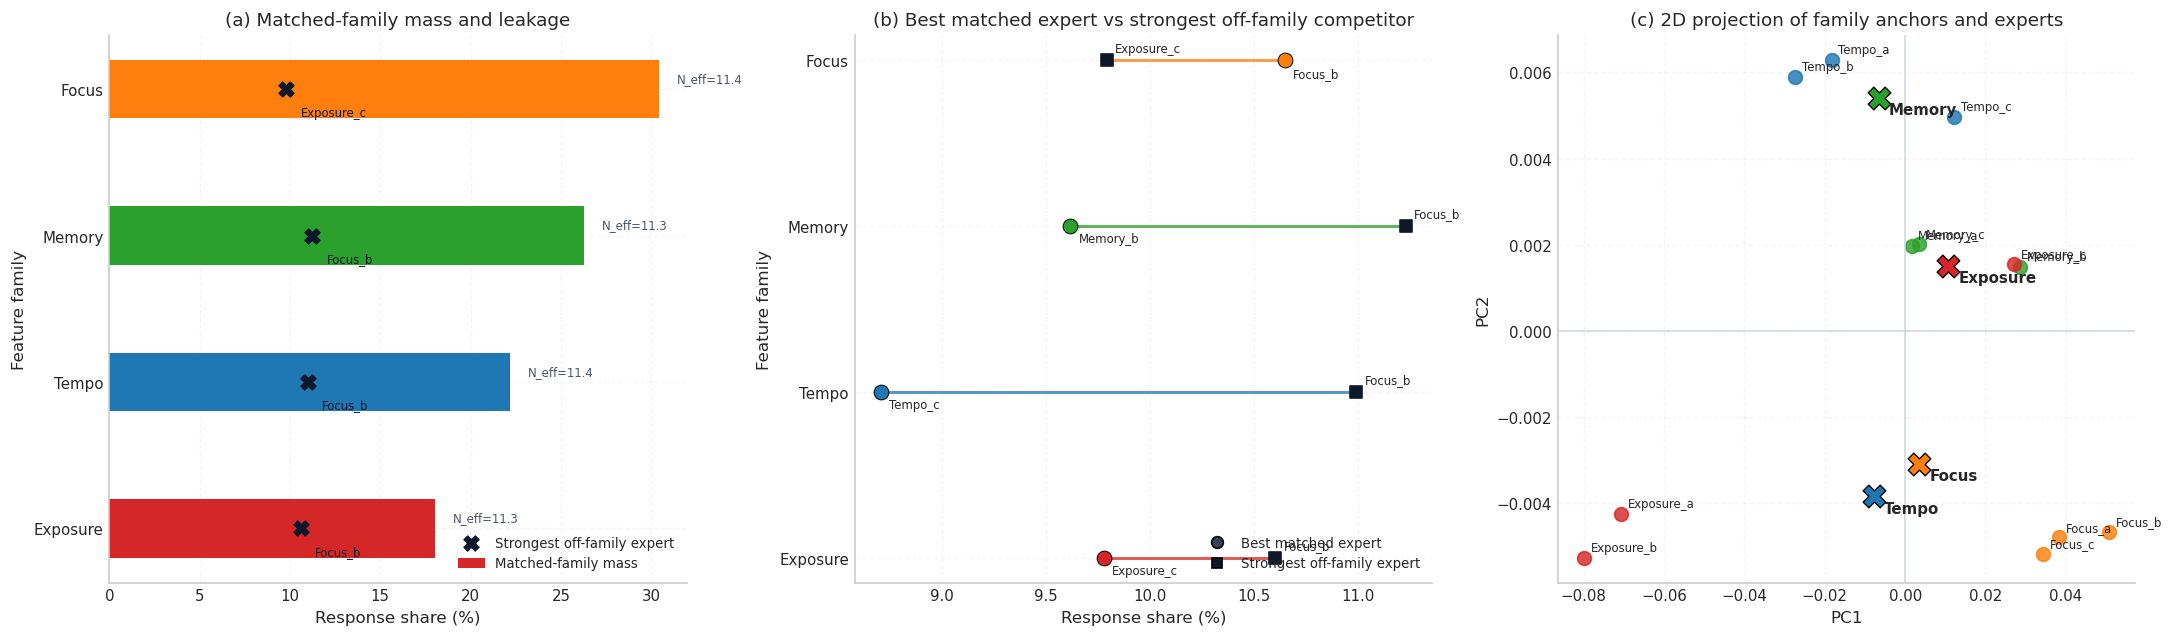

### 활용 포인트

이 그림은 specialization이 완전히 block-diagonal하지 않더라도, family-aligned mass와 leakage를 함께 읽게 만든다. 왼쪽은 matching family expert들에 얼마나 질량이 모이는지, 가운데는 best matched expert가 strongest off-family competitor와 얼마나 붙는지를 보여준다. 즉 sparse routing이 의미 없는 랜덤 분산은 아니지만, 아직 leakage가 남아 있다는 점까지 정직하게 드러내는 appendix figure로 쓰기 좋다.

In [17]:
BEST_DIAG_CANDIDATES = [
    Path("/workspace/FeaturedMoE/experiments/run/artifacts/results/fmoe_full/diag/raw/best_valid_diag.json"),
    Path("/workspace/FeaturedMoE/experiments/run/artifacts/results/fmoe_n4/diag/raw/best_valid_diag.json"),
]


def project_2d(matrix: np.ndarray) -> np.ndarray:
    centered = matrix - matrix.mean(axis=0, keepdims=True)
    if centered.ndim != 2 or centered.shape[0] == 0:
        return np.zeros((0, 2), dtype=float)
    _, _, vt = np.linalg.svd(centered, full_matrices=False)
    coords = centered @ vt.T[:, :2]
    if coords.shape[1] == 1:
        coords = np.column_stack([coords[:, 0], np.zeros(coords.shape[0])])
    return coords[:, :2]


def load_family_expert_matrix(diag_paths):
    for path in diag_paths:
        if not path.exists():
            continue
        payload = json.loads(path.read_text())
        for stage_key, stage_payload in payload.get("stage_metrics", {}).items():
            heatmap = stage_payload.get("feature_family_expert_heatmap", {})
            values = heatmap.get("values", [])
            family_names = heatmap.get("family_names", [])
            expert_names = stage_payload.get("expert_names", [])
            if values and family_names and expert_names:
                matrix = np.asarray(values, dtype=float)
                row_sums = matrix.sum(axis=1, keepdims=True)
                normalized = np.divide(matrix, row_sums, out=np.zeros_like(matrix), where=row_sums > 0)
                stage_name = stage_key.split("@")[0]
                return normalized, family_names, expert_names, stage_name, path, "json"

    family_names = ["Tempo", "Focus", "Memory", "Exposure"]
    expert_names = [
        "Tempo_a", "Tempo_b", "Tempo_c",
        "Focus_a", "Focus_b", "Focus_c",
        "Memory_a", "Memory_b", "Memory_c",
        "Exposure_a", "Exposure_b", "Exposure_c",
    ]
    normalized = np.array([
        [0.20, 0.19, 0.23, 0.10, 0.08, 0.07, 0.04, 0.03, 0.03, 0.01, 0.01, 0.01],
        [0.09, 0.08, 0.09, 0.18, 0.21, 0.20, 0.05, 0.04, 0.03, 0.01, 0.01, 0.01],
        [0.05, 0.04, 0.04, 0.06, 0.07, 0.06, 0.18, 0.21, 0.21, 0.03, 0.03, 0.02],
        [0.02, 0.02, 0.02, 0.03, 0.03, 0.03, 0.05, 0.06, 0.05, 0.22, 0.24, 0.23],
    ], dtype=float)
    return normalized, family_names, expert_names, "macro", Path("demo"), "demo"


def effective_expert_count(values):
    values = np.asarray(values, dtype=float)
    denom = np.square(values).sum()
    if denom <= 0:
        return 0.0
    return 1.0 / denom


specialization_matrix, specialization_families, specialization_experts, specialization_stage, specialization_path, specialization_mode = load_family_expert_matrix(BEST_DIAG_CANDIDATES)
heatmap_df = pd.DataFrame(specialization_matrix, index=specialization_families, columns=specialization_experts)

family_summary_rows = []
comparison_rows = []
for family_name, row in heatmap_df.iterrows():
    values = row.to_numpy(dtype=float)
    same_family_cols = [column for column in heatmap_df.columns if column.split("_")[0].lower() == family_name.lower()]
    off_family_cols = [column for column in heatmap_df.columns if column not in same_family_cols]
    same_family_row = row[same_family_cols].sort_values(ascending=False)
    off_family_row = row[off_family_cols].sort_values(ascending=False)
    same_family_mass = float(row[same_family_cols].sum())
    top_same_label = same_family_row.index[0]
    top_same_value = float(same_family_row.iloc[0])
    top_off_label = off_family_row.index[0]
    top_off_value = float(off_family_row.iloc[0])
    family_summary_rows.append({
        "feature_family": family_name,
        "matched_family_mass_pct": same_family_mass * 100.0,
        "top_offfamily_share_pct": top_off_value * 100.0,
        "top_offfamily_label": top_off_label,
        "effective_experts": effective_expert_count(values),
    })
    comparison_rows.append({
        "feature_family": family_name,
        "matched_label": top_same_label,
        "matched_share_pct": top_same_value * 100.0,
        "offfamily_label": top_off_label,
        "offfamily_share_pct": top_off_value * 100.0,
    })

family_summary_df = pd.DataFrame(family_summary_rows).sort_values("matched_family_mass_pct", ascending=True).reset_index(drop=True)
comparison_df = pd.DataFrame(comparison_rows)

expert_coords = project_2d(specialization_matrix.T)
family_coords = project_2d(specialization_matrix)
expert_plot_df = pd.DataFrame({
    "pc1": expert_coords[:, 0],
    "pc2": expert_coords[:, 1],
    "label": specialization_experts,
    "family": [name.split("_")[0] for name in specialization_experts],
})
family_plot_df = pd.DataFrame({
    "pc1": family_coords[:, 0],
    "pc2": family_coords[:, 1],
    "label": specialization_families,
    "family": specialization_families,
})

show_data_badge({"specialization": specialization_mode}, f"specialization scorecard는 {specialization_stage} stage diagnostic matrix를 사용합니다.")
display(family_summary_df.round(2))

fig, axes = plt.subplots(1, 3, figsize=(18.0, 5.2), constrained_layout=True)
colors = _color_map(specialization_families)

y_positions = np.arange(len(family_summary_df))
bar_colors = [colors[family] for family in family_summary_df["feature_family"]]
axes[0].barh(y_positions, family_summary_df["matched_family_mass_pct"], color=bar_colors, height=0.40, label="Matched-family mass")
axes[0].scatter(
    family_summary_df["top_offfamily_share_pct"],
    y_positions,
    marker="X",
    s=82,
    color="#0f172a",
    linewidth=0.8,
    label="Strongest off-family expert",
    zorder=3,
)
for idx, row in family_summary_df.iterrows():
    axes[0].text(row["matched_family_mass_pct"] + 1.0, idx + 0.05, f"N_eff={row['effective_experts']:.1f}", fontsize=7, color="#475569")
    axes[0].text(row["top_offfamily_share_pct"] + 0.8, idx - 0.18, row["top_offfamily_label"], fontsize=7, color="#0f172a")
axes[0].set_yticks(y_positions)
axes[0].set_yticklabels(family_summary_df["feature_family"])
axes[0].set_title("(a) Matched-family mass and leakage")
axes[0].set_xlabel("Response share (%)")
axes[0].set_ylabel("Feature family")
axes[0].grid(axis="x", alpha=0.20)
axes[0].legend(frameon=False, loc="lower right")

for idx, family in enumerate(family_summary_df["feature_family"]):
    row = comparison_df[comparison_df["feature_family"] == family].iloc[0]
    axes[1].plot(
        [row["matched_share_pct"], row["offfamily_share_pct"]],
        [idx, idx],
        color=colors[family],
        linewidth=1.8,
        alpha=0.75,
    )
    axes[1].scatter(row["matched_share_pct"], idx, marker="o", s=78, color=colors[family], edgecolor="black", linewidth=0.6, zorder=3)
    axes[1].scatter(row["offfamily_share_pct"], idx, marker="s", s=56, color="#0f172a", zorder=3)
    axes[1].annotate(row["matched_label"], (row["matched_share_pct"], idx), textcoords="offset points", xytext=(5, -10), fontsize=7)
    axes[1].annotate(row["offfamily_label"], (row["offfamily_share_pct"], idx), textcoords="offset points", xytext=(5, 5), fontsize=7)
axes[1].set_yticks(y_positions)
axes[1].set_yticklabels(family_summary_df["feature_family"])
axes[1].set_title("(b) Best matched expert vs strongest off-family competitor")
axes[1].set_xlabel("Response share (%)")
axes[1].set_ylabel("Feature family")
axes[1].grid(axis="x", alpha=0.20)
matched_handle = Line2D([0], [0], marker="o", color="none", markerfacecolor="#334155", markeredgecolor="black", markersize=7, label="Best matched expert")
off_handle = Line2D([0], [0], marker="s", color="none", markerfacecolor="#0f172a", markersize=6, label="Strongest off-family expert")
axes[1].legend(handles=[matched_handle, off_handle], frameon=False, loc="lower right")

for _, row in expert_plot_df.iterrows():
    axes[2].scatter(row["pc1"], row["pc2"], s=68, color=colors[row["family"]], alpha=0.82)
    axes[2].annotate(row["label"], (row["pc1"], row["pc2"]), textcoords="offset points", xytext=(4, 4), fontsize=7)
for _, row in family_plot_df.iterrows():
    axes[2].scatter(row["pc1"], row["pc2"], s=185, marker="X", color=colors[row["family"]], edgecolor="black", linewidth=0.8)
    axes[2].annotate(row["label"], (row["pc1"], row["pc2"]), textcoords="offset points", xytext=(6, -10), fontsize=9, fontweight="bold")
axes[2].axhline(0.0, color="#cbd5e1", linewidth=0.9)
axes[2].axvline(0.0, color="#cbd5e1", linewidth=0.9)
axes[2].set_title("(c) 2D projection of family anchors and experts")
axes[2].set_xlabel("PC1")
axes[2].set_ylabel("PC2")

saved_paths = export_figure(fig, "00_storyboard_specialization_scorecard", RESULTS_ROOT)
display(Markdown("Saved figures: " + ", ".join(str(path) for path in saved_paths)))
plt.show()

story_note(
    "활용 포인트",
    "이 그림은 specialization이 완전히 block-diagonal하지 않더라도, family-aligned mass와 leakage를 함께 읽게 만든다. 왼쪽은 matching family expert들에 얼마나 질량이 모이는지, 가운데는 best matched expert가 strongest off-family competitor와 얼마나 붙는지를 보여준다. 즉 sparse routing이 의미 없는 랜덤 분산은 아니지만, 아직 leakage가 남아 있다는 점까지 정직하게 드러내는 appendix figure로 쓰기 좋다."
)


## 7. Geometry View With Explicit Provenance

A geometry plot is still useful, but only if the reader can immediately tell whether it comes from real router-input PCA or from a derived proxy.

This section keeps the figure as qualitative support and makes the provenance explicit:

- real PCA artifacts are shown directly when available,
- otherwise the plot is labeled as a proxy derived from the specialization matrix,
- a second panel summarizes centroid separation and within-group spread instead of repeating the same scatter twice.

That makes the figure easier to defend in a paper appendix.

<div style='padding:10px 14px;border-radius:10px;border:2px solid #1d4ed8;background:#eff6ff;color:#1d4ed8;font-weight:800;display:inline-block;letter-spacing:0.02em'>CAUTION: PROXY / DERIVED VIEW</div><div style='margin-top:8px;color:#334155;font-size:13px;line-height:1.45'>geometry view는 실제 router-input PCA가 있으면 그대로 사용하고, 없으면 specialization matrix에서 유도한 proxy를 사용합니다.<br><br>주의: 이 출력은 실제 raw artifact 대신 파생된 proxy view를 포함한다. 정성 시각화에는 쓸 수 있지만, 직접적인 정량 근거로 과대해석하면 안 된다.</div>

Saved figures: /workspace/FeaturedMoE/writing/results/generated_figures/00_storyboard_geometry_view.png, /workspace/FeaturedMoE/writing/results/generated_figures/00_storyboard_geometry_view.pdf

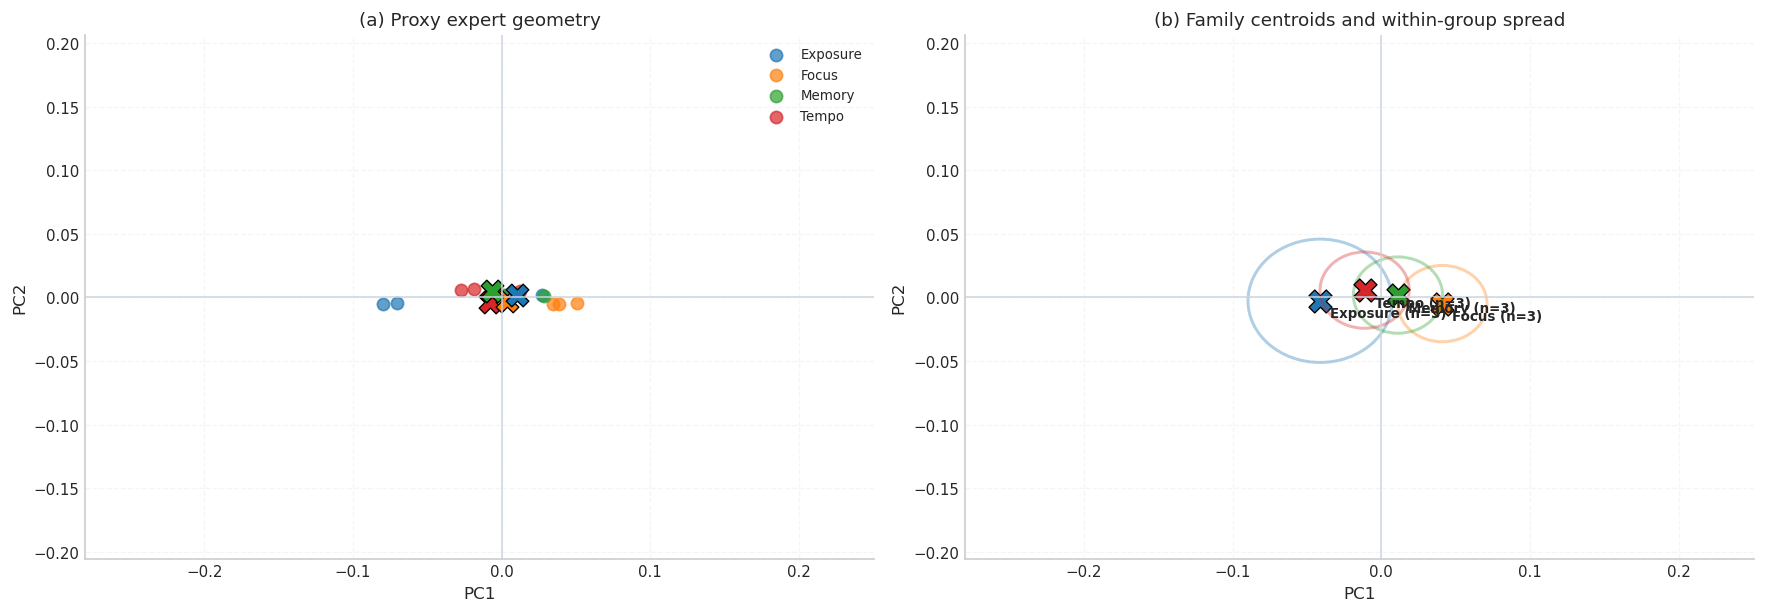

### 활용 포인트

이 그림은 geometry figure의 provenance를 명확히 하면서도 단순 산점도 반복을 피한다. 왼쪽은 실제 PCA 또는 proxy cloud 자체를 보여주되, proxy인 경우 family anchor는 marker로만 남겨 clutter를 줄였다. 오른쪽은 group centroid와 spread를 요약해서 cluster separation이 어느 정도인지 더 읽기 쉽게 만든다. 본문에서 강한 주장 근거로 쓰기보다는, appendix에서 routing structure가 시각적으로도 정돈되어 있다는 보조 증거로 쓰는 편이 안전하다.

In [18]:
PCA_CANDIDATES = [
    Path("/workspace/FeaturedMoE/experiments/run/artifacts/results/fmoe_full/diag/tier_c_viz/viz_router_input_pca.csv.gz"),
    Path("/workspace/FeaturedMoE/experiments/run/artifacts/results/fmoe_n4/diag/tier_c_viz/viz_router_input_pca.csv.gz"),
]


def load_pca_or_proxy(candidate_paths):
    for pca_path in candidate_paths:
        if pca_path.exists():
            df = pd.read_csv(pca_path, compression="gzip")
            if not df.empty and {"pc1", "pc2"}.issubset(df.columns):
                if "top1_label" not in df.columns:
                    df["top1_label"] = "route"
                if "stage_name" not in df.columns:
                    df["stage_name"] = "stage"
                return df, "csv", pca_path

    if "load_family_expert_matrix" in globals() and "project_2d" in globals():
        matrix, family_names, expert_names, stage_name, source_path, _ = load_family_expert_matrix(BEST_DIAG_CANDIDATES)
        expert_coords = project_2d(matrix.T)
        family_coords = project_2d(matrix)
        proxy_df = pd.concat([
            pd.DataFrame({
                "pc1": expert_coords[:, 0],
                "pc2": expert_coords[:, 1],
                "label": expert_names,
                "group": [name.split("_")[0] for name in expert_names],
                "point_type": "expert",
                "stage_name": stage_name,
            }),
            pd.DataFrame({
                "pc1": family_coords[:, 0],
                "pc2": family_coords[:, 1],
                "label": family_names,
                "group": family_names,
                "point_type": "family",
                "stage_name": stage_name,
            }),
        ], ignore_index=True)
        return proxy_df, "proxy", source_path

    demo = pd.DataFrame([
        {"pc1": -1.8, "pc2": 1.1, "label": "Tempo", "group": "Tempo", "point_type": "family", "stage_name": "macro"},
        {"pc1": -1.4, "pc2": 0.9, "label": "Tempo_a", "group": "Tempo", "point_type": "expert", "stage_name": "macro"},
        {"pc1": -0.7, "pc2": 0.2, "label": "Focus", "group": "Focus", "point_type": "family", "stage_name": "mid"},
        {"pc1": -0.5, "pc2": 0.1, "label": "Focus_a", "group": "Focus", "point_type": "expert", "stage_name": "mid"},
        {"pc1": 0.4, "pc2": -0.3, "label": "Memory", "group": "Memory", "point_type": "family", "stage_name": "mid"},
        {"pc1": 0.8, "pc2": -0.4, "label": "Memory_a", "group": "Memory", "point_type": "expert", "stage_name": "mid"},
        {"pc1": 1.5, "pc2": -1.0, "label": "Exposure", "group": "Exposure", "point_type": "family", "stage_name": "micro"},
        {"pc1": 1.9, "pc2": -1.2, "label": "Exposure_a", "group": "Exposure", "point_type": "expert", "stage_name": "micro"},
    ])
    return demo, "demo", Path("demo")


def summarize_group_geometry(points_df, group_col):
    summary_rows = []
    for group_name, subset in points_df.groupby(group_col):
        center_x = float(subset["pc1"].mean())
        center_y = float(subset["pc2"].mean())
        spread = float(np.sqrt(((subset["pc1"] - center_x) ** 2 + (subset["pc2"] - center_y) ** 2).mean()))
        summary_rows.append({
            "group": group_name,
            "pc1": center_x,
            "pc2": center_y,
            "spread": spread,
            "count": int(len(subset)),
        })
    return pd.DataFrame(summary_rows)


pca_df, pca_mode, pca_source = load_pca_or_proxy(PCA_CANDIDATES)
show_data_badge({"router_geometry": pca_mode}, "geometry view는 실제 router-input PCA가 있으면 그대로 사용하고, 없으면 specialization matrix에서 유도한 proxy를 사용합니다.")

if pca_mode == "csv":
    point_df = pca_df.copy()
    point_df["group"] = point_df["top1_label"].astype(str)
    anchor_df = pd.DataFrame(columns=point_df.columns)
    cloud_title = "(a) Router-input PCA cloud"
    summary_title = "(b) Route centroids and within-group spread"
else:
    point_df = pca_df[pca_df["point_type"] == "expert"].copy()
    anchor_df = pca_df[pca_df["point_type"] == "family"].copy()
    cloud_title = "(a) Proxy expert geometry"
    summary_title = "(b) Family centroids and within-group spread"

geometry_summary_df = summarize_group_geometry(point_df, "group")
geometry_groups = list(dict.fromkeys(geometry_summary_df["group"].tolist()))
colors = _color_map(geometry_groups)

fig, axes = plt.subplots(1, 2, figsize=(14.6, 5.0), constrained_layout=True)

for group_name, subset in point_df.groupby("group"):
    axes[0].scatter(
        subset["pc1"],
        subset["pc2"],
        color=colors[group_name],
        s=54,
        alpha=0.70,
        label=group_name,
    )
if pca_mode == "csv" and len(point_df) <= 24:
    for _, row in point_df.iterrows():
        axes[0].annotate(row.get("label", row["group"]), (row["pc1"], row["pc2"]), textcoords="offset points", xytext=(4, 4), fontsize=7)
if not anchor_df.empty:
    for _, row in anchor_df.iterrows():
        axes[0].scatter(row["pc1"], row["pc2"], color=colors[row["group"]], marker="X", s=185, edgecolor="black", linewidth=0.8)
axes[0].axhline(0.0, color="#cbd5e1", linewidth=0.9)
axes[0].axvline(0.0, color="#cbd5e1", linewidth=0.9)
axes[0].set_title(cloud_title)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
if len(geometry_groups) <= 8:
    axes[0].legend(frameon=False, loc="best", fontsize=8)

for _, row in geometry_summary_df.iterrows():
    circle = plt.Circle((row["pc1"], row["pc2"]), max(row["spread"], 0.03), fill=False, color=colors[row["group"]], alpha=0.35, linewidth=1.8)
    axes[1].add_patch(circle)
    axes[1].scatter(row["pc1"], row["pc2"], marker="X", s=190, color=colors[row["group"]], edgecolor="black", linewidth=0.8)
    axes[1].annotate(f"{row['group']} (n={int(row['count'])})", (row["pc1"], row["pc2"]), textcoords="offset points", xytext=(6, -10), fontsize=8, fontweight="bold")
axes[1].axhline(0.0, color="#cbd5e1", linewidth=0.9)
axes[1].axvline(0.0, color="#cbd5e1", linewidth=0.9)
axes[1].set_title(summary_title)
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

all_x = pd.concat([point_df["pc1"], anchor_df["pc1"]]) if not anchor_df.empty else point_df["pc1"]
all_y = pd.concat([point_df["pc2"], anchor_df["pc2"]]) if not anchor_df.empty else point_df["pc2"]
x_min, x_max = float(all_x.min()), float(all_x.max())
y_min, y_max = float(all_y.min()), float(all_y.max())
x_pad = max((x_max - x_min) * 0.12, 0.2)
y_pad = max((y_max - y_min) * 0.12, 0.2)
for ax in axes:
    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

saved_paths = export_figure(fig, "00_storyboard_geometry_view", RESULTS_ROOT)
display(Markdown("Saved figures: " + ", ".join(str(path) for path in saved_paths)))
plt.show()

story_note(
    "활용 포인트",
    "이 그림은 geometry figure의 provenance를 명확히 하면서도 단순 산점도 반복을 피한다. 왼쪽은 실제 PCA 또는 proxy cloud 자체를 보여주되, proxy인 경우 family anchor는 marker로만 남겨 clutter를 줄였다. 오른쪽은 group centroid와 spread를 요약해서 cluster separation이 어느 정도인지 더 읽기 쉽게 만든다. 본문에서 강한 주장 근거로 쓰기보다는, appendix에서 routing structure가 시각적으로도 정돈되어 있다는 보조 증거로 쓰는 편이 안전하다."
)


## Suggested Paper Flow

A compact paper flow based on the revised figures above would be:

1. `Table`: overall ranking quality.
2. `Figure`: routing control, with both quality and consistency.
3. `Figure`: stage structure, with removal losses and dense / single-stage alternatives.
4. `Figure`: auxiliary-objective sanity plus cue-level diagnostics.
5. `Appendix figure`: cross-dataset slice atlas for seen/unseen, popularity, and session retention.
6. `Appendix figure`: specialization scorecard without a heatmap.
7. `Appendix figure`: geometry view with explicit provenance.

This order reads better than a sequence of disconnected ablation bars because each figure answers a different reviewer question.

If the final budget is tight, keep the main paper focused on:

- routing control,
- stage structure,
- diagnostic sanity.

If there is room for only one appendix figure, the cross-dataset slice atlas is now the strongest first choice because it addresses robustness directly across multiple datasets.